<a href="https://colab.research.google.com/github/ngyxntthaoo/IS6404.CH201-Phan-tich-du-lieu-nang-cao/blob/main/Lab04c_Lec06_TimeSeries_ML_Forecasting_PTDL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Notebook Structure (by Phase)

| Phase | Description |
|---|---|
| 1 | Introduction, Environment Setup, Random Seed, `OUTPUT_DIR` |
| 2 | Problem Formulation + Data Loading & Preview |
| 3 | Exploratory Data Analysis (EDA) |
| 4 | Time-Based Split (Protocol & Verification) |
| 5 | Evaluation Metrics (MAE, RMSE, sMAPE) |
| 6 | Baseline Models: Classical → Tabular ML → Chronos-Bolt Zero-Shot |
| 7 | Proposed Framework: Chronos-2, Ensembling, Optuna HPO, Feature Importance |
| 8 | Validation Benchmark & Model Comparison |
| 9 | Multi-Dimensional Error Analysis (Proposed Model) |
| 10 | Ablation Study (Components & Feature Groups) |
| 11 | Final Test Evaluation & Grouped Performance |
| 12 | Artifact & Reproducibility Export (`outputs/`) |

# Phase 1 — Setup & reproducibility

In [1]:


import os, json, sys, platform, warnings

from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("python:", sys.version)
print("platform:", platform.platform())
print("numpy:", np.__version__)
print("pandas:", pd.__version__)

warnings.filterwarnings("ignore")


python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
platform: Linux-6.12.90+-x86_64-with-glibc2.35
numpy: 2.0.2
pandas: 2.3.3


# Phase 2 — Problem Formulation

Task: **Multi-Series Retail Demand Forecasting** across 100 daily time series (5 stores × 20 products).

### Formal Task Specification

| Element | Specification |
|---|---|
| **Target Variable** | `Units Sold` — daily sales volume per (Store ID, Product ID) pair |
| **Data Frequency** | Daily |
| **Forecast Horizon ($H$)** | **7 days** (`HORIZON_DAYS = 7`) |
| **Forecast Origins** | Validation: `2023-06-30` · Test: `2023-10-31` |
| **Prediction Type** | **Direct Multi-Step Ahead** — jointly predicting $\hat{y}_{t+1}, \ldots, \hat{y}_{t+7}$ from a fixed forecast origin |
| **Number of Series** | $N = 100$ individual series (5 stores × 20 products) |

### Data Loading & Preview

In [2]:
import os

print(os.listdir("/kaggle/input/datasets/atomicd/retail-store-inventory-and-demand-forecasting"))

['sales_data.csv']


In [3]:
# Install dependencies as needed:
!pip install kagglehub[pandas-datasets]
import kagglehub

# Download latest version
path = kagglehub.dataset_download("atomicd/retail-store-inventory-and-demand-forecasting")

print("Path to dataset files:", path)

df = pd.read_csv(os.path.join(path, "sales_data.csv"))

Path to dataset files: /kaggle/input/datasets/atomicd/retail-store-inventory-and-demand-forecasting


In [4]:
DATA_PATH = '/kaggle/input/datasets/atomicd/retail-store-inventory-and-demand-forecasting/sales_data.csv'
print("Path to dataset file:", DATA_PATH)

df = pd.read_csv(DATA_PATH)
df

Path to dataset file: /kaggle/input/datasets/atomicd/retail-store-inventory-and-demand-forecasting/sales_data.csv


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,2024-01-30,S005,P0016,Toys,North,233,63,0,29.80,5,Snowy,0,32.23,Winter,0,64
75996,2024-01-30,S005,P0017,Toys,North,137,115,141,42.92,5,Snowy,0,40.73,Winter,0,137
75997,2024-01-30,S005,P0018,Clothing,North,197,44,0,17.81,10,Snowy,0,19.41,Winter,0,68
75998,2024-01-30,S005,P0019,Furniture,North,125,58,0,151.72,0,Snowy,0,143.71,Winter,0,84


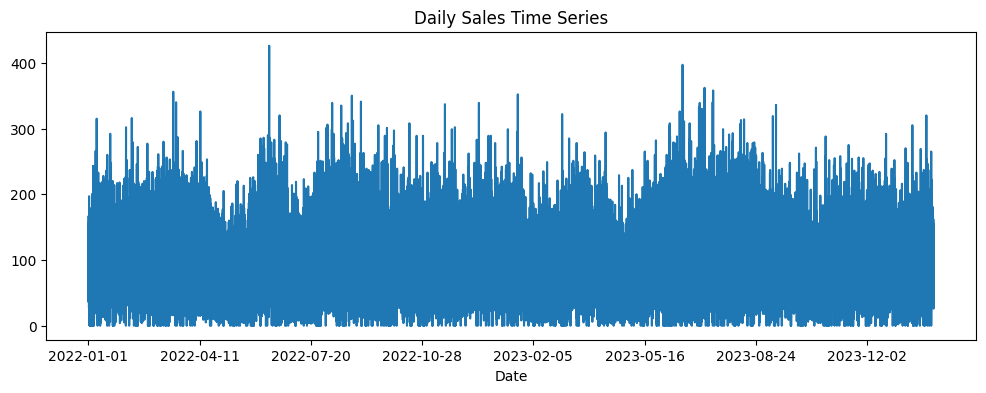

,Inventory Level,Units Sold,Units Ordered,Price,Discount,Promotion,Competitor Pricing,Epidemic,Demand
count,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000
mean,301.062842,88.827316,89.090645,67.726028,9.087039,0.328947,69.454029,0.200000,104.317158
std,226.510161,43.994525,162.404627,39.377899,7.475781,0.469834,40.943818,0.400003,46.964801
min,0.000000,0.000000,0.000000,4.740000,0.000000,0.000000,4.290000,0.000000,4.000000
25%,136.000000,58.000000,0.000000,31.997500,5.000000,0.000000,32.620000,0.000000,71.000000
50%,227.000000,84.000000,0.000000,64.500000,10.000000,0.000000,65.700000,0.000000,100.000000
75%,408.000000,114.000000,121.000000,95.830000,10.000000,1.000000,97.932500,0.000000,133.000000
max,2267.000000,426.000000,1616.000000,228.030000,25.000000,1.000000,261.220000,1.000000,430.000000


In [5]:
df.set_index("Date")["Units Sold"].plot(figsize=(12,4), title="Daily Sales Time Series")
plt.show()
df.describe()


# Phase 3 — Exploratory Data Analysis (EDA)


[3.1 / 3.3 / 3.4] Seasonal Decomposition


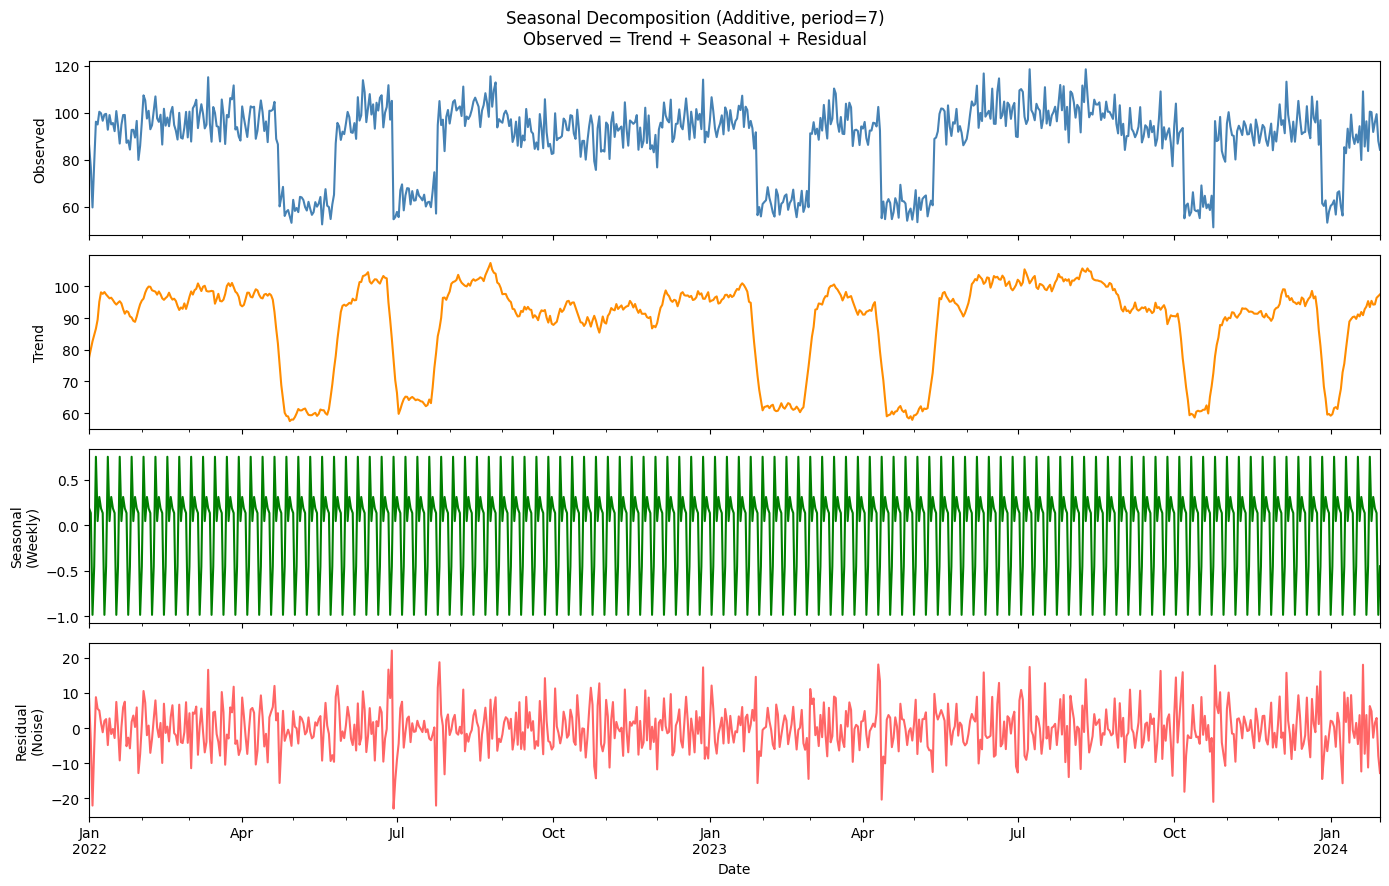

Noise-to-Signal Ratio (resid_std / total_std): 0.405
Trend Amplitude: 49.92 units
Seasonal Amplitude: 1.74 units

[3.2] ACF / PACF Autocorrelation & Seasonality


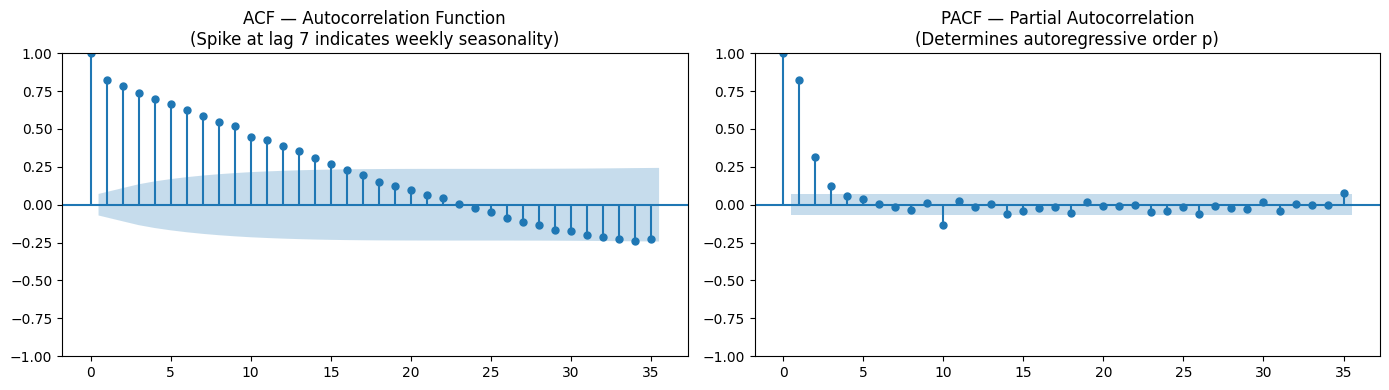


[3.6] ADF Stationarity Test
  ADF Statistic : -4.9190
  p-value       : 0.000032
  Result: Stationary (p < 0.05)
  Critical [1%]: -3.4391 *
  Critical [5%]: -2.8654 *
  Critical [10%]: -2.5688 *

[3.5] Shock / Outlier Detection
  Anomalous days (|z| > 3): 0 / 760 days (0.0%)


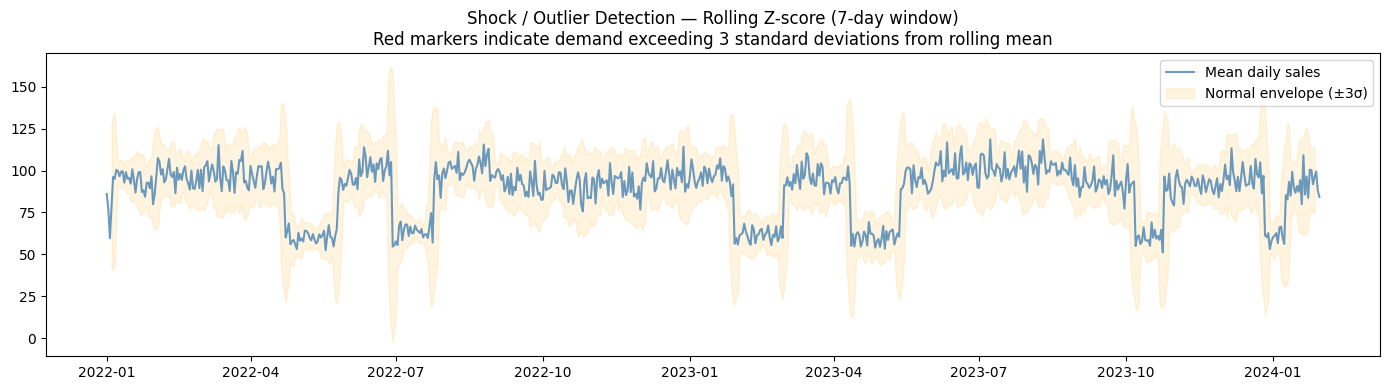

In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

# Daily aggregate mean series across all 100 panel time series
ts_agg = df.groupby("Date")["Units Sold"].mean().sort_index()
ts_agg.index = pd.to_datetime(ts_agg.index)

# ── 3.1, 3.3, 3.4: Seasonal Decomposition ────────────────────────────────────
# Decompose: Observed = Trend + Seasonal + Residual
# period=7 for daily data with strong weekly periodicity
print("[3.1 / 3.3 / 3.4] Seasonal Decomposition")
decomp = seasonal_decompose(ts_agg, model="additive", period=7, extrapolate_trend="freq")

fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)
decomp.observed.plot(ax=axes[0], color="steelblue")
axes[0].set_ylabel("Observed")
decomp.trend.plot(ax=axes[1], color="darkorange")
axes[1].set_ylabel("Trend")
decomp.seasonal.plot(ax=axes[2], color="green")
axes[2].set_ylabel("Seasonal\n(Weekly)")
decomp.resid.plot(ax=axes[3], color="red", alpha=0.6)
axes[3].set_ylabel("Residual\n(Noise)")
fig.suptitle("Seasonal Decomposition (Additive, period=7)\n"
             "Observed = Trend + Seasonal + Residual", fontsize=12)
plt.tight_layout()
plt.show()

noise_ratio = decomp.resid.dropna().std() / decomp.observed.std()
trend_range = decomp.trend.dropna().max() - decomp.trend.dropna().min()
seasonal_amp = decomp.seasonal.max() - decomp.seasonal.min()

print(f"Noise-to-Signal Ratio (resid_std / total_std): {noise_ratio:.3f}")
print(f"Trend Amplitude: {trend_range:.2f} units")
print(f"Seasonal Amplitude: {seasonal_amp:.2f} units")

# ── 3.2: ACF / PACF ──────────────────────────────────────────────────────────
# ACF: measures correlation between series and its h-step lagged values
# PACF: measures partial correlation at lag h removing intermediate lag effects
print("\n[3.2] ACF / PACF Autocorrelation & Seasonality")
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(ts_agg.dropna(),  lags=35, ax=axes[0],
         title="ACF — Autocorrelation Function\n(Spike at lag 7 indicates weekly seasonality)")
plot_pacf(ts_agg.dropna(), lags=35, ax=axes[1],
          title="PACF — Partial Autocorrelation\n(Determines autoregressive order p)")
plt.tight_layout()
plt.show()

# ── 3.6: ADF Stationarity Test ───────────────────────────────────────────────
# Augmented Dickey-Fuller (ADF) test: H0 = presence of unit root (non-stationary)
# p < 0.05 rejects H0 => stationary => ARIMA integration order d=0
print("\n[3.6] ADF Stationarity Test")
adf_stat, adf_p, _, _, adf_crit, _ = adfuller(ts_agg.dropna(), autolag="AIC")
print(f"  ADF Statistic : {adf_stat:.4f}")
print(f"  p-value       : {adf_p:.6f}")
print("  Result: Stationary (p < 0.05)" if adf_p < 0.05 else "  Result: Non-stationary (p >= 0.05)")
for level, cv in adf_crit.items():
    marker = "*" if adf_stat < cv else " "
    print(f"  Critical [{level}]: {cv:.4f} {marker}")

# ── 3.5: Shock / Outlier Detection ───────────────────────────────────────────
# Rolling z-score to identify anomalous demand events
# z = (y - rolling_mean) / rolling_std; |z| > 3 indicates an outlier
print("\n[3.5] Shock / Outlier Detection")
roll_mean = ts_agg.rolling(window=7, center=True).mean()
roll_std  = ts_agg.rolling(window=7, center=True).std()
z_scores  = (ts_agg - roll_mean) / (roll_std + 1e-8)
outliers  = ts_agg[z_scores.abs() > 3]
pct = 100 * len(outliers) / len(ts_agg)
print(f"  Anomalous days (|z| > 3): {len(outliers)} / {len(ts_agg)} days ({pct:.1f}%)")

plt.figure(figsize=(14, 4))
plt.plot(ts_agg.index, ts_agg.values, label="Mean daily sales", alpha=0.8, color="steelblue")
if len(outliers):
    plt.scatter(outliers.index, outliers.values, color="red", zorder=5, s=40,
                label=f"Shock/Outlier ({len(outliers)} days, |z| > 3σ)")
plt.fill_between(ts_agg.index, roll_mean - 3*roll_std, roll_mean + 3*roll_std,
                 alpha=0.12, color="orange", label="Normal envelope (±3σ)")
plt.legend(loc="upper right")
plt.title("Shock / Outlier Detection — Rolling Z-score (7-day window)\n"
          "Red markers indicate demand exceeding 3 standard deviations from rolling mean")
plt.tight_layout()
plt.show()

# Phase 4 — Time-Based Splitting Protocol

| Specification | Configuration |
|---|---|
| **Target Variable** | `Units Sold` — daily sales volume per (Store ID, Product ID) series. |
| **Temporal Frequency** | **Daily**. |
| **Forecast Horizon ($H$)** | **$H = 7$ days** (`HORIZON_DAYS = 7`). |
| **Forecast Origins** | **Validation:** Origin at `TRAIN_END` (`2023-06-30`). **Test:** Origin at `VAL_END` (`2023-10-31`). |
| **Forecasting Scheme** | **Direct Multi-Step Ahead:** Joint trajectory forecast $\hat{y}_{t+1}, \ldots, \hat{y}_{t+H}$ from each origin without rolling lookahead leakage. |

In [7]:
# Time-based split protocol (strictly temporal, preventing data leakage)
HORIZON_DAYS = 7   # forecasting horizon — all models predict H=7 steps 
FORECAST_GAP = 0   # Gap between train end and val start; 0 = contiguous evaluation
                   # (per-series lag features never cross the split boundary)
TRAIN_END = pd.Timestamp("2023-06-30")
VAL_END = pd.Timestamp("2023-10-31")

# Ensure Date is datetime even if prior preprocessing cell was not rerun
if not pd.api.types.is_datetime64_any_dtype(df["Date"]):
    df["Date"] = pd.to_datetime(df["Date"])

train_df = df[df["Date"] <= TRAIN_END].copy()
val_df = df[(df["Date"] > TRAIN_END) & (df["Date"] <= VAL_END)].copy()
test_df = df[df["Date"] > VAL_END].copy()

print(f"Forecast horizon (H): {HORIZON_DAYS} days")
print(f"Train end: {TRAIN_END.date()}")
print(f"Validation: {(TRAIN_END + pd.Timedelta(days=1)).date()} -> {VAL_END.date()}")
print(f"Test: > {VAL_END.date()}")
len(train_df), len(val_df), len(test_df)


Forecast horizon (H): 7 days
Train end: 2023-06-30
Validation: 2023-07-01 -> 2023-10-31
Test: > 2023-10-31


(54600, 12300, 9100)

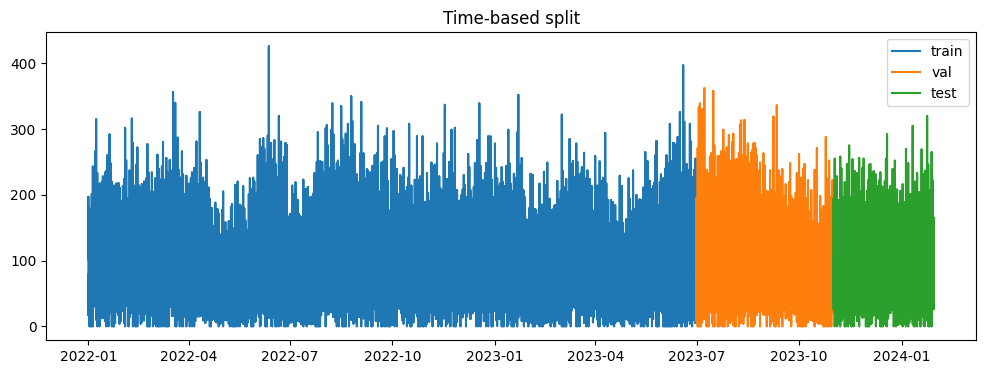

In [8]:
plt.figure(figsize=(12,4))
plt.plot(train_df["Date"], train_df["Units Sold"], label="train")
plt.plot(val_df["Date"], val_df["Units Sold"], label="val")
plt.plot(test_df["Date"], test_df["Units Sold"], label="test")
plt.legend()
plt.title("Time-based split")
plt.show()


## Phase 5 — Evaluation Metrics



In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def smape(y_true, y_pred, eps=1e-8):
    """Symmetric MAPE — bounded [0, 200%], handles y=0 gracefully.
    Replaces naive MAPE which diverges when Units Sold = 0.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(200 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred) + eps)))

def eval_forecast(y_true, y_pred, prefix="val", y_train=None):
    return {
        f"{prefix}_MAE":   float(mean_absolute_error(y_true, y_pred)),
        f"{prefix}_RMSE":  rmse(y_true, y_pred),
        f"{prefix}_sMAPE": smape(y_true, y_pred),   # bounded [0,200%], replaces MAPE
    }


# Phase 6 — Baseline models

- Group 1 — Classical baselines: Naive · Seasonal naive · ARIMA · SARIMAX · ETS · 
-  Group 2 — ML-based: Ridge regression · HistGradientBoosting · LSTM univariate · LSTM multivariate, Prophet
- Group 3 — Pre-trained foundation model: Chronos-Bolt-Small (zero-shot, univariate)


## Group 1 — Naive Forecast (Flat Baseline)

In [10]:
# Forecast val using last observed point from train, recursively as a flat forecast
last_train_value = train_df["Units Sold"].iloc[-1]
val_pred_naive = np.repeat(last_train_value, len(val_df))

eval_forecast(val_df["Units Sold"], val_pred_naive, prefix="val")


{'val_MAE': 35.027723577235776,
 'val_RMSE': 46.558625514034425,
 'val_sMAPE': 40.39816056245148}

## Group 1 — Seasonal Naive Forecast


In [11]:
def seasonal_naive_predict(history_values, horizon, season_length=7):
    history_values = list(history_values)
    preds = []
    for i in range(horizon):
        preds.append(history_values[-season_length + (i % season_length)])
    return np.array(preds)

val_pred_snaive = seasonal_naive_predict(train_df["Units Sold"].values, len(val_df), season_length=7)
eval_forecast(val_df["Units Sold"], val_pred_snaive, prefix="val")


{'val_MAE': 45.40471544715447,
 'val_RMSE': 59.39119449665782,
 'val_sMAPE': 58.120835320580525}

## Group 1 — Classical Autoregressive Models (ARIMA & SARIMAX)

In [12]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# --- ARIMA (non-seasonal) baseline ---
arima = ARIMA(
    train_df["Units Sold"],
    order=(2,1,2)
)
arima_fit = arima.fit()
val_pred_arima = arima_fit.forecast(steps=len(val_df))

arima_val_metrics = eval_forecast(val_df["Units Sold"], val_pred_arima, prefix="val")
print('ARIMA baseline metrics:')
print(arima_val_metrics)

# --- SARIMAX seasonal baseline ---
sarimax = SARIMAX(
    train_df["Units Sold"],
    order=(2,1,2),
    seasonal_order=(1,0,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarimax_fit = sarimax.fit(disp=False)
val_pred_sarimax = sarimax_fit.forecast(steps=len(val_df))

sarimax_val_metrics = eval_forecast(val_df["Units Sold"], val_pred_sarimax, prefix="val")
print('SARIMAX baseline metrics:')
print(sarimax_val_metrics)

ARIMA baseline metrics:
{'val_MAE': 35.32002259768432, 'val_RMSE': 45.69781881982683, 'val_sMAPE': 40.431360550864134}


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMAX baseline metrics:
{'val_MAE': 35.31660598733458, 'val_RMSE': 45.697667073354836, 'val_sMAPE': 40.428687918561614}


## Group 1 — Error, Trend, Seasonal (ETS) Exponential Smoothing

In [13]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# ETS additive trend + additive weekly seasonality
ets = ExponentialSmoothing(
    train_df["Units Sold"],
    trend="add",
    seasonal="add",
    seasonal_periods=7
).fit(optimized=True)

val_pred_ets = ets.forecast(len(val_df))

ets_val_metrics = eval_forecast(
    val_df["Units Sold"],
    val_pred_ets,
    prefix="val")
print("ETS baseline metrics:")
print(ets_val_metrics)


ETS baseline metrics:
{'val_MAE': 35.416337953839175, 'val_RMSE': 45.9320491981215, 'val_sMAPE': 40.53231533472983}


## Group 1 — Additive Regressive Baseline (Prophet)


In [14]:
import logging
import contextlib
from prophet import Prophet

# Suppress Prophet / Stan verbose output
logging.getLogger("prophet").setLevel(logging.ERROR)
logging.getLogger("cmdstanpy").setLevel(logging.ERROR)

@contextlib.contextmanager
def _suppress_prophet_output():
    """Redirect prophet's stdout/stderr during fitting."""
    import io, sys
    old_stdout, old_stderr = sys.stdout, sys.stderr
    sys.stdout = sys.stderr = io.StringIO()
    try:
        yield
    finally:
        sys.stdout, sys.stderr = old_stdout, old_stderr

def prophet_fn(train_dates, train_values, horizon):
    """Fit Prophet on training series and forecast `horizon` steps ahead.
    Returns np.array of length `horizon`.
    """
    df_fit = pd.DataFrame({
        'ds': pd.to_datetime(train_dates),
        'y':  train_values.astype(float),
    })
    # Drop any NaN rows (Prophet raises an error if y contains NaN)
    df_fit = df_fit.dropna()
    if len(df_fit) < 14:
        raise ValueError(f"Insufficient historical data after dropna: {len(df_fit)} rows")

    model = Prophet(
        daily_seasonality=False,
        weekly_seasonality=True,
        yearly_seasonality=False,
    )
    with _suppress_prophet_output():
        model.fit(df_fit)

    # make_future_dataframe: construct future timestamps via pd.Timedelta to avoid freq='D' deprecation warnings
    last_date = df_fit["ds"].max()
    future_dates = pd.DataFrame({
        "ds": [last_date + pd.Timedelta(days=i) for i in range(1, horizon + 1)]
    })
    forecast = model.predict(future_dates)
    return np.clip(forecast["yhat"].values, 0, None)

# ── Per-series evaluation: H=7 from a single forecast origin ───────────
prophet_series_records = []
prophet_scores = {'val_MAE': [], 'val_RMSE': [], 'val_sMAPE': []}
prophet_errors = []

for (store, product), grp in df.groupby(['Store ID', 'Product ID']):
    s = grp.set_index('Date')['Units Sold'].sort_index()
    s.index = pd.to_datetime(s.index)

    train_s = s[s.index <= TRAIN_END]
    val_s   = s[(s.index > TRAIN_END) & (s.index <= VAL_END)]

    # Require sufficient training data and at least HORIZON_DAYS evaluation rows
    if len(train_s) < 14 or len(val_s) < HORIZON_DAYS:
        continue

    try:
        # Forecast H=7 
        y_pred = prophet_fn(train_s.index, train_s.values, HORIZON_DAYS)
        y_true = val_s.values[:HORIZON_DAYS].astype(float)  # take first 7 validation steps
        metrics = eval_forecast(y_true, y_pred, prefix='val', y_train=train_s.values)
    except Exception as e:
        prophet_errors.append({'store': store, 'product': product, 'error': str(e)})
        continue

    for k in prophet_scores:
        prophet_scores[k].append(metrics[k])

    prophet_series_records.append({
        'store': store, 'product': product,
        **{k: round(float(v), 4) for k, v in metrics.items()},
    })

prophet_details_df = pd.DataFrame(prophet_series_records)

prophet_val_metrics = {k: float(np.nanmean(v)) for k, v in prophet_scores.items()}
print(f'Prophet per-series (H={HORIZON_DAYS}): {len(prophet_series_records)} / 100 series evaluated')
if prophet_errors:
    print(f'  Failed series ({len(prophet_errors)}):')
    for e in prophet_errors[:3]:
        print(f"     Store={e['store']} Product={e['product']}: {e['error']}")
print('Prophet val metrics (mean across series):')
for k, v in prophet_val_metrics.items():
    print(f'  {k}: {v:.4f}')
print(f'Per-series breakdown: prophet_details_df ({len(prophet_series_records)} rows)')


Prophet per-series (H=7): 100 / 100 series evaluated
Prophet val metrics (mean across series):
  val_MAE: 35.7392
  val_RMSE: 44.5651
  val_sMAPE: 37.8408
Per-series breakdown: prophet_details_df (100 rows)


### Feature Engineering Pipeline


In [15]:
def make_ts_features(df_in):
    df_feat = df_in.copy()
    df_feat = df_feat.sort_values("Date").reset_index(drop=True)
    df_feat["Date"] = pd.to_datetime(df_feat["Date"])
    # Lag features
    for lag in [1, 2, 3, 7, 14, 28]:
        df_feat[f"lag_{lag}"] = df_feat["Units Sold"].shift(lag)

    # Rolling features
    for window in [7, 14, 28]:
        df_feat[f"roll_mean_{window}"] = df_feat["Units Sold"].shift(1).rolling(window).mean()
        df_feat[f"roll_std_{window}"] = df_feat["Units Sold"].shift(1).rolling(window).std()

    # Calendar features
    df_feat["dayofweek"] = df_feat["Date"].dt.dayofweek
    df_feat["month"] = df_feat["Date"].dt.month
    df_feat["dayofyear"] = df_feat["Date"].dt.dayofyear

    return df_feat

df_feat = make_ts_features(df)
df_feat.head(10)


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,...,lag_28,roll_mean_7,roll_std_7,roll_mean_14,roll_std_14,roll_mean_28,roll_std_28,dayofweek,month,dayofyear
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,1,1
1,2022-01-01,S004,P0013,Groceries,West,136,104,385,20.24,10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,1,1
2,2022-01-01,S004,P0012,Electronics,West,111,111,113,118.15,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,1,1
3,2022-01-01,S004,P0011,Clothing,West,195,60,293,52.89,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,1,1
4,2022-01-01,S004,P0010,Groceries,West,223,120,597,30.02,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,1,1
5,2022-01-01,S004,P0009,Clothing,West,206,106,299,110.47,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,1,1
6,2022-01-01,S004,P0008,Furniture,West,281,59,0,100.64,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,1,1
7,2022-01-01,S004,P0007,Groceries,West,185,43,253,24.34,5,...,NaN,94.571429,24.670206,NaN,NaN,NaN,NaN,5,1,1
8,2022-01-01,S004,P0006,Groceries,West,206,48,162,35.33,0,...,NaN,86.142857,30.980793,NaN,NaN,NaN,NaN,5,1,1
9,2022-01-01,S004,P0005,Clothing,West,289,197,0,89.23,10,...,NaN,78.142857,32.779204,NaN,NaN,NaN,NaN,5,1,1


In [16]:
# Split again after feature generation (same full train/val/test windows)
train_feat = df_feat[df_feat["Date"] <= TRAIN_END].copy()
val_feat = df_feat[(df_feat["Date"] > TRAIN_END) & (df_feat["Date"] <= VAL_END)].copy()
test_feat = df_feat[df_feat["Date"] > VAL_END].copy()

feature_cols = [c for c in train_feat.columns if c not in ["Date", "Units Sold", "Store ID", "Product ID", "Category", "Region", "Weather Condition", "Seasonality", "Demand", "Units Ordered"]]

train_feat = train_feat.dropna().reset_index(drop=True)
val_feat = val_feat.dropna().reset_index(drop=True)
test_feat = test_feat.dropna().reset_index(drop=True)

X_train = train_feat[feature_cols]
y_train = train_feat["Units Sold"]
X_val = val_feat[feature_cols]
y_val = val_feat["Units Sold"]
X_test = test_feat[feature_cols]
y_test = test_feat["Units Sold"]

X_train.shape, X_val.shape, X_test.shape


((54572, 21), (12300, 21), (9100, 21))

## Group 2 — Ridge Regression with Lagged Features


In [17]:

_lag_cols  = [c for c in feature_cols if c.startswith("lag_")]
_roll_cols = [c for c in feature_cols if c.startswith("roll_")]
_cal_cols  = ["dayofweek", "month", "dayofyear"]
_exog_cols = [c for c in feature_cols if c not in set(_lag_cols + _roll_cols + _cal_cols)]

if _exog_cols:
    print(f"Exogenous features (known-future): {_exog_cols}")
else:
    print("No exogenous features detected — purely lag/rolling/calendar.")


def evaluate_rolling_horizon(model, context_end, df_all, feat_cols, prefix, horizon=HORIZON_DAYS):
    """Per-series H=7 recursive prediction without oracle lags.

    Parameters
    ----------
    model       : fitted sklearn model / Pipeline
    context_end : Timestamp — forecast origin (no data beyond this used)
    df_all      : full DataFrame (provides exogenous values for forecast window)
    feat_cols   : ordered list of feature column names the model expects
    prefix      : 'val' | 'test' | 'fold'
    """
    lag_keys  = [c for c in feat_cols if c.startswith("lag_")]
    roll_keys = [c for c in feat_cols if c.startswith("roll_")]
    exog_keys = [c for c in feat_cols if c not in set(lag_keys + roll_keys + _cal_cols)]

    scores  = {f"{prefix}_MAE": [], f"{prefix}_RMSE": [],
               f"{prefix}_sMAPE": []}
    records = []
    skipped = 0

    for (store, product), grp in df_all.groupby(["Store ID", "Product ID"]):
        grp = grp.sort_values("Date").copy()
        grp["Date"] = pd.to_datetime(grp["Date"])

        hist_grp   = grp[grp["Date"] <= pd.Timestamp(context_end)]
        future_grp = grp[grp["Date"] >  pd.Timestamp(context_end)].head(horizon)

        if len(hist_grp) < 28 or len(future_grp) < horizon:
            skipped += 1
            continue

        y_hist = list(hist_grp["Units Sold"].values.astype(float))
        y_true = future_grp["Units Sold"].values[:horizon].astype(float)

        preds = []
        for h in range(horizon):
            row       = future_grp.iloc[h]
            pred_date = pd.Timestamp(row["Date"])
            y_all     = np.array(y_hist + preds)   # history + recursive preds

            feat = {}

            # Lag features from available history (no oracle)
            for lag_col in lag_keys:
                lag = int(lag_col.split("_")[1])
                feat[lag_col] = float(y_all[-lag]) if len(y_all) >= lag else np.nan

            # Rolling features
            for roll_col in roll_keys:
                w   = int(roll_col.split("_")[-1])
                win = y_all[-w:] if len(y_all) >= w else y_all
                if "std" in roll_col:
                    feat[roll_col] = float(np.nanstd(win))  if len(win) > 1 else 0.0
                else:
                    feat[roll_col] = float(np.nanmean(win))

            # Calendar features (always known)
            feat["dayofweek"] = pred_date.dayofweek
            feat["month"]     = pred_date.month
            feat["dayofyear"] = pred_date.dayofyear

            # Exogenous: actual values from dataset (known-future externals)
            for col in exog_keys:
                feat[col] = float(row[col]) if col in row.index else 0.0

            feat_arr = np.array([[feat.get(c, 0.0) for c in feat_cols]])
            pred = float(np.clip(model.predict(feat_arr)[0], 0, None))
            preds.append(pred)

        y_pred = np.array(preds)
        m = eval_forecast(y_true, y_pred, prefix=prefix, y_train=np.array(y_hist))
        for k in scores:
            scores[k].append(m[k])
        records.append({
            "store": store, "product": product,
            **{k: round(float(m[k]), 4) for k in m}
        })

    agg = {k: float(np.nanmean(v)) for k, v in scores.items()}
    print(f"  [{prefix}] {len(records)} series evaluated, {skipped} skipped")
    return agg, records

def build_hgb_horizon_predictions(model, context_end, df_all, feat_cols, horizon=HORIZON_DAYS):
    lag_keys  = [c for c in feat_cols if c.startswith("lag_")]
    roll_keys = [c for c in feat_cols if c.startswith("roll_")]
    exog_keys = [c for c in feat_cols if c not in set(lag_keys + roll_keys + _cal_cols)]
    result    = {}

    for (store, product), grp in df_all.groupby(["Store ID", "Product ID"]):
        grp = grp.sort_values("Date").copy()
        grp["Date"] = pd.to_datetime(grp["Date"])
        hist_grp   = grp[grp["Date"] <= pd.Timestamp(context_end)]
        future_grp = grp[grp["Date"] >  pd.Timestamp(context_end)].head(horizon)

        if len(hist_grp) < 28 or len(future_grp) < horizon:
            continue

        y_hist = list(hist_grp["Units Sold"].values.astype(float))
        preds  = []

        for h in range(horizon):
            row       = future_grp.iloc[h]
            pred_date = pd.Timestamp(row["Date"])
            y_all     = np.array(y_hist + preds)

            feat = {}
            for lag_col in lag_keys:
                lag = int(lag_col.split("_")[1])
                feat[lag_col] = float(y_all[-lag]) if len(y_all) >= lag else np.nan
            for roll_col in roll_keys:
                w   = int(roll_col.split("_")[-1])
                win = y_all[-w:] if len(y_all) >= w else y_all
                feat[roll_col] = (float(np.nanstd(win)) if "std" in roll_col and len(win) > 1
                                  else float(np.nanmean(win)))
            feat["dayofweek"] = pred_date.dayofweek
            feat["month"]     = pred_date.month
            feat["dayofyear"] = pred_date.dayofyear
            for col in exog_keys:
                feat[col] = float(row[col]) if col in row.index else 0.0

            feat_arr = np.array([[feat.get(c, 0.0) for c in feat_cols]])
            pred = float(np.clip(model.predict(feat_arr)[0], 0, None))
            preds.append(pred)

        result[(store, product)] = np.array(preds)

    return result

Exogenous features (known-future): ['Inventory Level', 'Price', 'Discount', 'Promotion', 'Competitor Pricing', 'Epidemic']


In [18]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

ridge_ts = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

ridge_ts.fit(X_train, y_train)
val_pred_ridge = ridge_ts.predict(X_val)

eval_forecast(y_val, val_pred_ridge, prefix="val")

ridge_val_c_metrics, _ = evaluate_rolling_horizon(ridge_ts, TRAIN_END, df, feature_cols, prefix="val")


  [val] 100 series evaluated, 0 skipped


## Group 2 — HistGradientBoosting Regressor (Tabular Tree Ensemble)


In [19]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgb_ts = HistGradientBoostingRegressor(
    random_state=RANDOM_SEED,
    max_depth=5,
    learning_rate=0.05
)

hgb_ts.fit(X_train, y_train)
val_pred_hgb = hgb_ts.predict(X_val)

eval_forecast(y_val, val_pred_hgb, prefix="val")

hgb_val_c_metrics, _ = evaluate_rolling_horizon(hgb_ts, TRAIN_END, df, feature_cols, prefix="val")


  [val] 100 series evaluated, 0 skipped


## Group 2 — Deep Learning: Univariate LSTM


In [20]:
LOOKBACK_LSTM = 30
VERBOSE_WINDOWS = False
MAX_VERBOSE_STEPS = 8
EPOCHS_LSTM = 20

def log_window(tag, step, total_steps, history_dates, target_date, lookback, enabled=True, max_steps=8):
    if not enabled:
        return
    if not (step < max_steps or step == total_steps - 1):
        return
    start_idx = max(0, len(history_dates) - lookback)
    win_start = pd.Timestamp(history_dates[start_idx]).date()
    win_end = pd.Timestamp(history_dates[-1]).date()
    tgt = pd.Timestamp(target_date).date()
    print(f"[{tag} step={step:03d}] context_window: {win_start} -> {win_end} | target: {tgt}")

try:
    import torch
    import torch.nn as nn
    torch.manual_seed(RANDOM_SEED)

    class LSTMUni(nn.Module):
        def __init__(self, hidden_size=64):
            super().__init__()
            self.lstm = nn.LSTM(input_size=1, hidden_size=hidden_size, batch_first=True)
            self.dropout = nn.Dropout(0.2)
            self.fc = nn.Linear(hidden_size, 1)

        def forward(self, x):
            out, _ = self.lstm(x)
            out = self.dropout(out[:, -1, :])
            return self.fc(out).squeeze(-1)

    # Daily aggregate: authentic univariate sequence — mean Units Sold per day
    ts_daily = df.groupby("Date")["Units Sold"].mean().sort_index()
    ts_daily.index = pd.to_datetime(ts_daily.index)

    train_series = ts_daily.loc[ts_daily.index <= TRAIN_END].astype(float).values
    val_series = ts_daily.loc[(ts_daily.index > TRAIN_END) & (ts_daily.index <= VAL_END)].astype(float).values
    train_dates = ts_daily.loc[ts_daily.index <= TRAIN_END].index.values
    val_dates = ts_daily.loc[(ts_daily.index > TRAIN_END) & (ts_daily.index <= VAL_END)].index.values

    # PRACTICE: fit scaler on train only (avoid preprocessing leakage)
    mu = float(train_series.mean())
    sd = float(train_series.std()) + 1e-8
    train_norm = (train_series - mu) / sd

    X_lstm, y_lstm = [], []
    for i in range(len(train_norm) - LOOKBACK_LSTM):
        X_lstm.append(train_norm[i:i+LOOKBACK_LSTM])
        y_lstm.append(train_norm[i+LOOKBACK_LSTM])

    X_lstm = torch.tensor(np.array(X_lstm), dtype=torch.float32).unsqueeze(-1)
    y_lstm = torch.tensor(np.array(y_lstm), dtype=torch.float32)

    lstm_uni = LSTMUni(hidden_size=64)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(lstm_uni.parameters(), lr=1e-3)

    lstm_uni.train()
    for _ in range(EPOCHS_LSTM):
        optimizer.zero_grad()
        pred = lstm_uni(X_lstm)
        loss = criterion(pred, y_lstm)
        loss.backward()
        optimizer.step()

    lstm_uni.eval()
    val_pred_daily = []
    for t in range(len(val_series)):
        # History strictly includes training history + observed validation days prior to target step (true rolling)
        history = np.concatenate([train_series, val_series[:t]])
        history_dates = np.concatenate([train_dates, val_dates[:t]])
        history_norm = (history - mu) / sd

        if len(history_norm) < LOOKBACK_LSTM:
            pad = np.repeat(history_norm[0] if len(history_norm) else 0.0, LOOKBACK_LSTM - len(history_norm))
            context = np.concatenate([pad, history_norm])
        else:
            context = history_norm[-LOOKBACK_LSTM:]

        log_window(
            tag="VAL",
            step=t,
            total_steps=len(val_series),
            history_dates=history_dates,
            target_date=val_dates[t],
            lookback=LOOKBACK_LSTM,
            enabled=VERBOSE_WINDOWS,
            max_steps=MAX_VERBOSE_STEPS,
        )

        x = torch.tensor(context.reshape(1, LOOKBACK_LSTM, 1), dtype=torch.float32)
        with torch.no_grad():
            yhat_norm = float(lstm_uni(x).item())
        val_pred_daily.append(yhat_norm * sd + mu)

    val_pred_daily = np.array(val_pred_daily)

    # Broadcast daily predictions to panel rows for consistent evaluation metrics
    _lstm_val_lut = pd.DataFrame({"Date": pd.to_datetime(val_dates), "_p": val_pred_daily})
    val_pred_lstm_uni = (
        val_df[["Date"]]
        .assign(Date=lambda x: pd.to_datetime(x["Date"]))
        .merge(_lstm_val_lut, on="Date", how="left")["_p"]
        .values
    )

    print("LSTM-univariate baseline metrics:")
    eval_forecast(val_df["Units Sold"], val_pred_lstm_uni, prefix="val", y_train=train_df["Units Sold"])

except Exception as e:
    print("LSTM unavailable, fallback to naive. Reason:", e)
    val_pred_lstm_uni = np.repeat(train_df["Units Sold"].iloc[-1], len(val_df))
    eval_forecast(val_df["Units Sold"], val_pred_lstm_uni, prefix="val", y_train=train_df["Units Sold"])


LSTM-univariate baseline metrics:


## Group 2 — Deep Learning: Multivariate LSTM

In [21]:
try:
    LOOKBACK_LSTM_MULTI = LOOKBACK_LSTM  # synchronized with univariate LSTM lookback
except NameError:
    LOOKBACK_LSTM_MULTI = 30
EPOCHS_LSTM_MULTI = 20
BATCH_LSTM_MULTI = 512

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import TensorDataset, DataLoader
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import StandardScaler

    torch.manual_seed(RANDOM_SEED)

    class LSTMMulti(nn.Module):
        def __init__(self, n_feat, hidden_size=64):
            super().__init__()
            self.lstm = nn.LSTM(input_size=n_feat, hidden_size=hidden_size, num_layers=1, batch_first=True)
            self.dropout = nn.Dropout(0.2)
            self.fc = nn.Linear(hidden_size, 1)

        def forward(self, x):
            out, _ = self.lstm(x)
            out = self.dropout(out[:, -1, :])
            return self.fc(out).squeeze(-1)

    # ── Daily aggregate: mean Units Sold and mean feature values per calendar day
    _daily_lm = (
        df_feat.groupby(pd.to_datetime(df_feat["Date"]).dt.normalize())
        .agg({"Units Sold": "mean", **{c: "mean" for c in feature_cols}})
        .sort_index()
    )
    _daily_lm.index = pd.to_datetime(_daily_lm.index)

    train_dlm = _daily_lm.loc[_daily_lm.index <= TRAIN_END].copy()
    val_dlm = _daily_lm.loc[(_daily_lm.index > TRAIN_END) & (_daily_lm.index <= VAL_END)].copy()

    # Target normalization: scaled on training targets, input features normalized via StandardScaler
    mu_y_lm = float(train_dlm["Units Sold"].mean())
    sd_y_lm = float(train_dlm["Units Sold"].std()) + 1e-8

    _imp_lm = SimpleImputer(strategy="median")
    _sc_lm = StandardScaler()
    _imp_lm.fit(train_dlm[feature_cols].values)
    _sc_lm.fit(_imp_lm.transform(train_dlm[feature_cols].values))

    def _lm_X_from_hist(hist: pd.DataFrame):
        """hist: daily rows (chronological), columns include feature_cols."""
        raw = hist[feature_cols].values
        X = _sc_lm.transform(_imp_lm.transform(raw)).astype(np.float32)
        if len(X) < LOOKBACK_LSTM_MULTI:
            pad = np.repeat(X[0:1], LOOKBACK_LSTM_MULTI - len(X), axis=0)
            X = np.vstack([pad, X])
        else:
            X = X[-LOOKBACK_LSTM_MULTI:]
        return X

    _nfeat_lm = len(feature_cols)
    _Xs, _ys = [], []
    for _i in range(LOOKBACK_LSTM_MULTI, len(train_dlm)):
        _win = train_dlm.iloc[_i - LOOKBACK_LSTM_MULTI : _i]
        _Xs.append(_lm_X_from_hist(_win))
        _ys.append((float(train_dlm.iloc[_i]["Units Sold"]) - mu_y_lm) / sd_y_lm)

    _Xtr_m = np.stack(_Xs, axis=0)
    _ytr_m = np.array(_ys, dtype=np.float32)
    _ds_m = TensorDataset(torch.from_numpy(_Xtr_m), torch.from_numpy(_ytr_m))
    _dl_m = DataLoader(_ds_m, batch_size=BATCH_LSTM_MULTI, shuffle=True)

    lstm_multi = LSTMMulti(n_feat=_nfeat_lm)
    _crit_m = nn.MSELoss()
    _opt_m = torch.optim.Adam(lstm_multi.parameters(), lr=1e-3)

    lstm_multi.train()
    for _ in range(EPOCHS_LSTM_MULTI):
        for xb, yb in _dl_m:
            _opt_m.zero_grad()
            pr = lstm_multi(xb)
            loss = _crit_m(pr, yb)
            loss.backward()
            _opt_m.step()

    lstm_multi.eval()
    val_pred_daily_lm = []
    val_dates_lm = val_dlm.index.values
    with torch.no_grad():
        for _t in range(len(val_dlm)):
            _hist = pd.concat([train_dlm, val_dlm.iloc[:_t]])
            x = torch.from_numpy(_lm_X_from_hist(_hist).reshape(1, LOOKBACK_LSTM_MULTI, _nfeat_lm))
            _yh = float(lstm_multi(x).item()) * sd_y_lm + mu_y_lm
            val_pred_daily_lm.append(max(_yh, 0.0))

    val_pred_daily_lm = np.array(val_pred_daily_lm)

    _lut_lm = pd.DataFrame({"Date": pd.to_datetime(val_dates_lm), "_p": val_pred_daily_lm})
    val_pred_lstm_multi = (
        val_df[["Date"]]
        .assign(Date=lambda x: pd.to_datetime(x["Date"]))
        .merge(_lut_lm, on="Date", how="left")["_p"]
        .values
    )

    print("LSTM-multivariate (daily aggregate) — validation metrics:")
    eval_forecast(val_df["Units Sold"], val_pred_lstm_multi, prefix="val", y_train=train_df["Units Sold"])

except Exception as e:
    print("LSTM multivariate unavailable:", e)
    val_pred_lstm_multi = np.repeat(float(train_df["Units Sold"].iloc[-1]), len(val_df))
    eval_forecast(val_df["Units Sold"], val_pred_lstm_multi, prefix="val", y_train=train_df["Units Sold"])


LSTM-multivariate (daily aggregate) — validation metrics:


## Group 3 — Foundation Model: Chronos-Bolt-Small (Zero-Shot)


In [22]:
# Model C: Chronos-Bolt-Small (zero-shot, no fine-tuning)
!pip install git+https://github.com/amazon-science/chronos-forecasting.git

CHRONOS_AVAILABLE = False
chronos_val_metrics = {k: np.nan for k in ['val_MAE','val_RMSE','val_sMAPE']}
chronos_val_records = []

try:
    from chronos import ChronosBoltPipeline
    import torch

    CHRONOS_MODEL_ID = "amazon/chronos-bolt-small"
    print(f'Loading {CHRONOS_MODEL_ID}...')
    chronos_pipeline = ChronosBoltPipeline.from_pretrained(
        CHRONOS_MODEL_ID, device_map="cpu", torch_dtype=torch.float32
    )
    print('Model loaded.')

    def run_chronos_per_series(context_end, prefix):
        """Batch Chronos inference. context_end: last date included in context tensor."""
        contexts, actuals_list, trains_list, series_keys = [], [], [], []
        n_skip = 0

        for (store, product), grp in df.groupby(['Store ID', 'Product ID']):
            s_ts = grp.set_index('Date')['Units Sold'].sort_index()
            s_ts.index = pd.to_datetime(s_ts.index)

            ctx_s = s_ts[s_ts.index <= pd.Timestamp(context_end)]
            eval_s = (
                s_ts[(s_ts.index > pd.Timestamp(TRAIN_END)) & (s_ts.index <= pd.Timestamp(VAL_END))]
                if prefix == 'val'
                else s_ts[s_ts.index > pd.Timestamp(VAL_END)]
            )

            if len(ctx_s) < 14 or len(eval_s) < HORIZON_DAYS:
                n_skip += 1
                continue

            contexts.append(torch.tensor(ctx_s.values.astype(np.float32)))
            actuals_list.append(eval_s.values[:HORIZON_DAYS].astype(float))  # fixed horizon
            trains_list.append(ctx_s.values.astype(float))
            series_keys.append((store, product))

        print(f'  {prefix}: {len(series_keys)} series accepted, {n_skip} skipped')

        if not contexts:
            print('  WARNING: no series passed filter — check date types and split boundaries')
            return {f'{prefix}_{m}': np.nan for m in ['MAE','RMSE','sMAPE']}, []

        # Single batched call — all series at once (fixed HORIZON_DAYS, within Bolt's 64-step limit)
        print(f'  Running batch predict: {len(contexts)} contexts, horizon={HORIZON_DAYS}...')
        forecasts = chronos_pipeline.predict(contexts, prediction_length=HORIZON_DAYS)
        preds_all = forecasts.median(dim=1).values.numpy()

        scores = {f'{prefix}_MAE': [], f'{prefix}_RMSE': [],
                  f'{prefix}_sMAPE': [], f'{prefix}_RMSE': []}
        records = []
        for i, (store, product) in enumerate(series_keys):
            y_pred = np.clip(preds_all[i], 0, None)  # shape: (HORIZON_DAYS,)
            m = eval_forecast(actuals_list[i], y_pred, prefix=prefix, y_train=trains_list[i])
            for k in scores:
                scores[k].append(m[k])
            records.append({'store': store, 'product': product,
                            **{k: round(float(m[k]), 4) for k in m}})

        return {k: float(np.nanmean(v)) for k, v in scores.items()}, records

    def _chronos_bolt_raw_dict(context_end, prefix):
        """{(Store, Product): np.ndarray(H)} — median Chronos-Bolt trajectory for blending with HGB (same filters as batch eval)."""
        contexts, series_keys = [], []
        n_skip = 0
        for (store, product), grp in df.groupby(["Store ID", "Product ID"]):
            s_ts = grp.set_index("Date")["Units Sold"].sort_index()
            s_ts.index = pd.to_datetime(s_ts.index)
            ctx_s = s_ts[s_ts.index <= pd.Timestamp(context_end)]
            eval_s = (
                s_ts[(s_ts.index > pd.Timestamp(TRAIN_END)) & (s_ts.index <= pd.Timestamp(VAL_END))]
                if prefix == "val"
                else s_ts[s_ts.index > pd.Timestamp(VAL_END)]
            )
            if len(ctx_s) < 14 or len(eval_s) < HORIZON_DAYS:
                n_skip += 1
                continue
            contexts.append(torch.tensor(ctx_s.values.astype(np.float32)))
            series_keys.append((store, product))
        print(f"  {prefix} (Bolt raw dict): {len(series_keys)} series accepted, {n_skip} skipped")
        if not contexts:
            return {}
        forecasts = chronos_pipeline.predict(contexts, prediction_length=HORIZON_DAYS)
        preds_all = forecasts.median(dim=1).values.numpy()
        return {
            series_keys[i]: np.clip(preds_all[i], 0, None)
            for i in range(len(series_keys))
        }

    # Validation: context = train split, eval = val split
    chronos_val_metrics, chronos_val_records = run_chronos_per_series(
        context_end=TRAIN_END, prefix='val'
    )
    print(f'Val metrics (mean across series): {chronos_val_metrics}')
    CHRONOS_AVAILABLE = True

except Exception as e:
    print(f'Chronos error: {type(e).__name__}: {e}')
    print('chronos_val_metrics set to NaN — check error above')

  Cloning https://github.com/amazon-science/chronos-forecasting.git to /tmp/pip-req-build-vd5n24p_
  Running command git clone --filter=blob:none --quiet https://github.com/amazon-science/chronos-forecasting.git /tmp/pip-req-build-vd5n24p_
  Resolved https://github.com/amazon-science/chronos-forecasting.git to commit 10afa9ebe016e514f9d7dc1aa873f66af57e116b
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for chronos-forecasting: filename=chronos_forecasting-2.3.3.dev0-py3-none-any.whl size=80892 sha256=ad86ed38dab4cd4cc0e845d22e3d9eacd7fbaca1cf259a9868ab82a65cf261e9
  Stored in directory: /tmp/pip-ephem-wheel-cache-uu4x0ls1/wheels/b9/a6/b5/75fca7306751a3bc92a63680f861f44a42a8776f6423cf0188
Successfully built chronos-forecasting
Loading amazon/chronos-bolt-small...


config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/191M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

Model loaded.
  val: 100 series accepted, 0 skipped
  Running batch predict: 100 contexts, horizon=7...
Val metrics (mean across series): {'val_MAE': 34.838957143511095, 'val_RMSE': 43.238280707061, 'val_sMAPE': 36.971266722465515}


## Phase 7 — Proposed Framework — Component (1): Chronos-2

In [23]:
CHRONOS2_AVAILABLE = False
chronos2_val_metrics = {k: np.nan for k in ["val_MAE", "val_RMSE", "val_sMAPE"]}
chronos2_val_records = []

try:
    import torch
    from chronos import BaseChronosPipeline

    CHRONOS2_MODEL_ID = "amazon/chronos-2"
    print(
        f"Loading {CHRONOS2_MODEL_ID} "
        "(proposed: Chronos-2 + per-series features, leakage-safe covariates)..."
    )

    chronos2_pipeline = BaseChronosPipeline.from_pretrained(
        CHRONOS2_MODEL_ID,
        device_map="cpu",
        torch_dtype=torch.float32,
    )
    print("Chronos-2 loaded.")

    _C2_TARGET = "Units Sold"
    _c2_target_list = [_C2_TARGET]

    _C2_LAGS = [1, 2, 3, 7, 14, 28]
    _C2_ROLL = [7, 14, 28]

    def _c2_series_features(g):
        """Per-series feature table; lags/rolls use only past values within this series."""
        g = g.sort_values("Date").copy()
        g["Date"] = pd.to_datetime(g["Date"])
        y = pd.to_numeric(g["Units Sold"], errors="coerce").astype(float)
        out = pd.DataFrame(
            {
                "Store ID": g["Store ID"].values,
                "Product ID": g["Product ID"].values,
                "Date": g["Date"].values,
                _C2_TARGET: y.values,
            }
        )
        for lag in _C2_LAGS:
            out[f"lag_{lag}"] = y.shift(lag)
        rv = y.shift(1)
        for w in _C2_ROLL:
            out[f"roll_mean_{w}"] = rv.rolling(w, min_periods=1).mean()
            out[f"roll_std_{w}"] = rv.rolling(w, min_periods=1).std()
        dt = g["Date"]
        out["dayofweek"] = dt.dt.dayofweek.astype(float)
        out["month"] = dt.dt.month.astype(float)
        out["dayofyear"] = dt.dt.dayofyear.astype(float)
        for ex in ("Price", "Discount"):
            if ex in g.columns:
                out[ex] = pd.to_numeric(g[ex], errors="coerce")
        return out

    _c2_past_cov = (
        [f"lag_{lag}" for lag in _C2_LAGS]
        + [f"roll_mean_{w}" for w in _C2_ROLL]
        + [f"roll_std_{w}" for w in _C2_ROLL]
        + ["dayofweek", "month", "dayofyear"]
        + [c for c in ("Price", "Discount") if c in df.columns]
    )

    _c2_future_cov = ["dayofweek", "month", "dayofyear"] + [
        c for c in ("Price", "Discount") if c in df.columns
    ]

    def _c2_f(v):
        return float(v) if pd.notna(v) else 0.0

    def _c2_extract_yhat(pred_df, sid, horizon=HORIZON_DAYS):
        """Median (0.5) trajectory for Units Sold."""
        _id_out = "item_id" if "item_id" in pred_df.columns else "id"
        _ts_out = "timestamp" if "timestamp" in pred_df.columns else None
        sub = pred_df[pred_df[_id_out] == sid]
        if "target_name" in sub.columns:
            sub = sub[sub["target_name"] == _C2_TARGET]
        if _ts_out is not None:
            sub = sub.sort_values(_ts_out)
        if len(sub) < horizon:
            return np.full(horizon, np.nan, dtype=float)
        qcols = [c for c in sub.columns if str(c) == "0.5" or (isinstance(c, str) and c.endswith(".5"))]
        if qcols:
            arr = sub[qcols[0]].values[:horizon].astype(float)
        elif "predictions" in sub.columns:
            arr = sub["predictions"].values[:horizon].astype(float)
        else:
            num_cols = [
                c
                for c in sub.columns
                if c not in (_id_out, _ts_out, "target_name")
                and str(sub[c].dtype).startswith(("float", "int"))
            ]
            arr = (
                sub[num_cols[-1]].values[:horizon].astype(float)
                if num_cols
                else np.full(horizon, np.nan)
            )
        return np.clip(arr, 0, None)

    def _chronos2_predict_core(context_end, prefix):
        """Execute predict_df once -> pred_dict (Units Sold), actuals, trains, series keys."""
        ctx_rows, fut_rows = [], []
        actuals_list, trains_list, series_keys = [], [], []
        n_skip = 0

        for (store, product), grp in df.groupby(["Store ID", "Product ID"], sort=False):
            feat = _c2_series_features(grp)

            ctx_panel = feat[feat["Date"] <= pd.Timestamp(context_end)].copy()
            if prefix == "val":
                eval_mask = (feat["Date"] > pd.Timestamp(TRAIN_END)) & (
                    feat["Date"] <= pd.Timestamp(VAL_END)
                )
            else:
                eval_mask = feat["Date"] > pd.Timestamp(VAL_END)
            eval_panel = feat[eval_mask].sort_values("Date")

            if len(ctx_panel) < 14 or len(eval_panel) < HORIZON_DAYS:
                n_skip += 1
                continue

            sid = f"{store}::{product}"
            series_keys.append((store, product))

            for _, r in ctx_panel.iterrows():
                row = {
                    "item_id": sid,
                    "timestamp": pd.Timestamp(r["Date"]),
                    _C2_TARGET: _c2_f(r[_C2_TARGET]),
                }
                for c in _c2_past_cov:
                    row[c] = _c2_f(r[c]) if c in r.index else 0.0
                ctx_rows.append(row)

            ev_head = eval_panel.head(HORIZON_DAYS)
            actuals_list.append(ev_head[_C2_TARGET].values.astype(float))
            trains_list.append(ctx_panel[_C2_TARGET].values.astype(float))

            for _, r in ev_head.iterrows():
                row = {"item_id": sid, "timestamp": pd.Timestamp(r["Date"])}
                for c in _c2_future_cov:
                    row[c] = _c2_f(r[c]) if c in r.index else 0.0
                fut_rows.append(row)

        print(
            f"  [{prefix}] Chronos-2 proposed: target={_c2_target_list}, "
            f"past_cov={len(_c2_past_cov)}, future_cov={_c2_future_cov}, "
            f"{len(series_keys)} series, {n_skip} skipped"
        )

        if not ctx_rows:
            return {}, [], [], []

        context_df = pd.DataFrame(ctx_rows)
        future_df = pd.DataFrame(fut_rows)

        kwargs = dict(
            prediction_length=HORIZON_DAYS,
            quantile_levels=[0.1, 0.5, 0.9],
            id_column="item_id",
            timestamp_column="timestamp",
            target=_c2_target_list,
            future_df=future_df,
        )

        pred_df = chronos2_pipeline.predict_df(context_df, **kwargs)

        pred_dict = {}
        for (store, product) in series_keys:
            sid = f"{store}::{product}"
            pred_dict[(store, product)] = _c2_extract_yhat(
                pred_df, sid, horizon=HORIZON_DAYS
            )

        return pred_dict, actuals_list, trains_list, series_keys

    def _chronos2_raw_dict(context_end, prefix):
        """{(Store,Product): array(H)} — matching format with _chronos_raw for HGB blending."""
        d, _, _, _ = _chronos2_predict_core(context_end, prefix)
        return d

    def _chronos2_predict_eval_slice(context_end, eval_dates):
        """Rolling slice evaluation: forecast exact eval_dates window (len <= HORIZON_DAYS)."""
        eval_dates = sorted({pd.Timestamp(d) for d in eval_dates})
        n_ev = len(eval_dates)
        if n_ev == 0 or n_ev > HORIZON_DAYS:
            return {}
        ctx_rows, fut_rows = [], []
        series_keys = []
        ctx_end_ts = pd.Timestamp(context_end)

        for (store, product), grp in df.groupby(["Store ID", "Product ID"], sort=False):
            feat = _c2_series_features(grp)
            ctx_panel = feat[feat["Date"] <= ctx_end_ts].copy()
            if len(ctx_panel) < 14:
                continue
            ev_rows = []
            bad = False
            for d in eval_dates:
                hit = feat[feat["Date"] == d]
                if len(hit) == 0:
                    bad = True
                    break
                ev_rows.append(hit.iloc[0])
            if bad:
                continue

            sid = f"{store}::{product}"
            series_keys.append((store, product))

            for _, r in ctx_panel.iterrows():
                row = {
                    "item_id": sid,
                    "timestamp": pd.Timestamp(r["Date"]),
                    _C2_TARGET: _c2_f(r[_C2_TARGET]),
                }
                for c in _c2_past_cov:
                    row[c] = _c2_f(r[c]) if c in r.index else 0.0
                ctx_rows.append(row)

            for r in ev_rows:
                row = {"item_id": sid, "timestamp": pd.Timestamp(r["Date"])}
                for c in _c2_future_cov:
                    row[c] = _c2_f(r[c]) if c in r.index else 0.0
                fut_rows.append(row)

        if not ctx_rows:
            return {}

        context_df = pd.DataFrame(ctx_rows)
        future_df = pd.DataFrame(fut_rows)

        kwargs = dict(
            prediction_length=n_ev,
            quantile_levels=[0.1, 0.5, 0.9],
            id_column="item_id",
            timestamp_column="timestamp",
            target=_c2_target_list,
            future_df=future_df,
        )
        pred_df = chronos2_pipeline.predict_df(context_df, **kwargs)

        pred_dict = {}
        for (store, product) in series_keys:
            sid = f"{store}::{product}"
            pred_dict[(store, product)] = _c2_extract_yhat(pred_df, sid, horizon=n_ev)
        return pred_dict

    def run_chronos2_per_series(context_end, prefix, *, keep_pred_dict=False):
        pred_dict, actuals_list, trains_list, series_keys = _chronos2_predict_core(
            context_end, prefix
        )
        if not pred_dict:
            empty_m = {f"{prefix}_{m}": np.nan for m in ["MAE", "RMSE", "sMAPE"]}
            if keep_pred_dict:
                return empty_m, [], {}
            return empty_m, []

        scores = {f"{prefix}_MAE": [], f"{prefix}_RMSE": [], f"{prefix}_sMAPE": []}
        records = []

        for i, key in enumerate(series_keys):
            m = eval_forecast(
                actuals_list[i],
                pred_dict[key],
                prefix=prefix,
                y_train=np.array(trains_list[i]),
            )
            for k in scores:
                scores[k].append(m[k])
            records.append(
                {"store": key[0], "product": key[1], **{x: round(float(m[x]), 4) for x in m}}
            )

        metrics = {k: float(np.nanmean(v)) for k, v in scores.items()}
        if keep_pred_dict:
            return metrics, records, pred_dict
        return metrics, records

    chronos2_val_metrics, chronos2_val_records = run_chronos2_per_series(TRAIN_END, "val")
    print(f"Val metrics Chronos-2 (mean across series): {chronos2_val_metrics}")
    pd.DataFrame(chronos2_val_records).to_csv(
        os.path.join(OUTPUT_DIR, "chronos2_val_details.csv"), index=False
    )
    CHRONOS2_AVAILABLE = True

except Exception as e:
    print(f"Chronos-2 error: {type(e).__name__}: {e}")
    print("→ chronos2_* metrics left NaN. Try: pip install -U 'chronos-forecasting>=2'")


Loading amazon/chronos-2 (proposed: Chronos-2 + per-series features, leakage-safe covariates)...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/478M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Chronos-2 loaded.
  [val] Chronos-2 proposed: target=['Units Sold'], past_cov=17, future_cov=['dayofweek', 'month', 'dayofyear', 'Price', 'Discount'], 100 series, 0 skipped
Val metrics Chronos-2 (mean across series): {'val_MAE': 34.18076136452811, 'val_RMSE': 42.3958570523132, 'val_sMAPE': 36.10950271728185}


#### Chronos-2 — Univariate Formulation (Zero-Shot)


In [24]:
# Chronos-2 — Univariate (only Units Sold; no covariates / no future_df)
CHRONOS2_UNI_AVAILABLE = False
chronos2_uni_val_metrics = {k: np.nan for k in ["val_MAE", "val_RMSE", "val_sMAPE"]}
chronos2_uni_val_records = []
chronos2_uni_test_metrics = {k: np.nan for k in ["test_MAE", "test_RMSE", "test_sMAPE"]}
chronos2_uni_test_records = []

try:
    import torch
    from chronos import BaseChronosPipeline

    if "chronos2_pipeline" not in globals() or chronos2_pipeline is None:
        chronos2_pipeline = BaseChronosPipeline.from_pretrained(
            "amazon/chronos-2",
            device_map="cpu",
            torch_dtype=torch.float32,
        )
        print("Loaded Chronos-2 pipeline for univariate cell.")
    else:
        print("Reusing chronos2_pipeline from previous cell.")

    _U_TARGET = "Units Sold"
    _u_target_list = [_U_TARGET]

    def _u_extract_yhat(pred_df, sid, horizon=HORIZON_DAYS):
        _id_out = "item_id" if "item_id" in pred_df.columns else "id"
        _ts_out = "timestamp" if "timestamp" in pred_df.columns else None
        sub = pred_df[pred_df[_id_out] == sid]
        if "target_name" in sub.columns:
            sub = sub[sub["target_name"] == _U_TARGET]
        if _ts_out is not None:
            sub = sub.sort_values(_ts_out)
        if len(sub) < horizon:
            return np.full(horizon, np.nan, dtype=float)
        qcols = [c for c in sub.columns if str(c) == "0.5" or (isinstance(c, str) and c.endswith(".5"))]
        if qcols:
            arr = sub[qcols[0]].values[:horizon].astype(float)
        elif "predictions" in sub.columns:
            arr = sub["predictions"].values[:horizon].astype(float)
        else:
            num_cols = [
                c for c in sub.columns
                if c not in (_id_out, _ts_out, "target_name")
                and str(sub[c].dtype).startswith(("float", "int"))
            ]
            arr = sub[num_cols[-1]].values[:horizon].astype(float) if num_cols else np.full(horizon, np.nan)
        return np.clip(arr, 0, None)

    def _chronos2_uni_predict_core(context_end, prefix):
        ctx_rows = []
        actuals_list, trains_list, series_keys = [], [], []
        n_skip = 0

        for (store, product), grp in df.groupby(["Store ID", "Product ID"], sort=False):
            grp = grp.sort_values("Date").copy()
            grp["Date"] = pd.to_datetime(grp["Date"])
            ctx_g = grp[grp["Date"] <= pd.Timestamp(context_end)]
            if prefix == "val":
                eval_g = grp[(grp["Date"] > pd.Timestamp(TRAIN_END)) & (grp["Date"] <= pd.Timestamp(VAL_END))]
            else:
                eval_g = grp[grp["Date"] > pd.Timestamp(VAL_END)]
            if len(ctx_g) < 14 or len(eval_g) < HORIZON_DAYS:
                n_skip += 1
                continue

            sid = f"{store}::{product}"
            series_keys.append((store, product))
            for _, r in ctx_g.iterrows():
                ctx_rows.append(
                    {
                        "item_id": sid,
                        "timestamp": pd.Timestamp(r["Date"]),
                        _U_TARGET: float(r[_U_TARGET]),
                    }
                )
            ev = eval_g.head(HORIZON_DAYS)
            actuals_list.append(ev[_U_TARGET].values.astype(float))
            trains_list.append(ctx_g[_U_TARGET].values.astype(float))

        print(f"  [{prefix}] Chronos-2 UNI: {len(series_keys)} series, {n_skip} skipped")

        if not ctx_rows:
            return {}, [], [], []

        context_df = pd.DataFrame(ctx_rows)
        kwargs = dict(
            prediction_length=HORIZON_DAYS,
            quantile_levels=[0.1, 0.5, 0.9],
            id_column="item_id",
            timestamp_column="timestamp",
            target=_u_target_list,
        )
        pred_df = chronos2_pipeline.predict_df(context_df, **kwargs)

        pred_dict = {}
        for (store, product) in series_keys:
            sid = f"{store}::{product}"
            pred_dict[(store, product)] = _u_extract_yhat(pred_df, sid, horizon=HORIZON_DAYS)
        return pred_dict, actuals_list, trains_list, series_keys

    def _chronos2_uni_predict_eval_slice(context_end, eval_dates):
        """Rolling slice evaluation — univariate without future_df."""
        eval_dates = sorted({pd.Timestamp(d) for d in eval_dates})
        n_ev = len(eval_dates)
        if n_ev == 0 or n_ev > HORIZON_DAYS:
            return {}
        ctx_rows = []
        series_keys = []
        ctx_end_ts = pd.Timestamp(context_end)

        for (store, product), grp in df.groupby(["Store ID", "Product ID"], sort=False):
            grp = grp.sort_values("Date").copy()
            grp["Date"] = pd.to_datetime(grp["Date"])
            ctx_g = grp[grp["Date"] <= ctx_end_ts]
            if len(ctx_g) < 14:
                continue
            ok = True
            for d in eval_dates:
                if len(grp[grp["Date"] == d]) == 0:
                    ok = False
                    break
            if not ok:
                continue

            sid = f"{store}::{product}"
            series_keys.append((store, product))

            for _, r in ctx_g.iterrows():
                ctx_rows.append(
                    {
                        "item_id": sid,
                        "timestamp": pd.Timestamp(r["Date"]),
                        _U_TARGET: float(r[_U_TARGET]),
                    }
                )

        if not ctx_rows:
            return {}

        context_df = pd.DataFrame(ctx_rows)
        kwargs = dict(
            prediction_length=HORIZON_DAYS,
            quantile_levels=[0.1, 0.5, 0.9],
            id_column="item_id",
            timestamp_column="timestamp",
            target=_u_target_list,
        )
        pred_df = chronos2_pipeline.predict_df(context_df, **kwargs)

        pred_dict = {}
        for (store, product) in series_keys:
            sid = f"{store}::{product}"
            pred_dict[(store, product)] = _u_extract_yhat(pred_df, sid, horizon=HORIZON_DAYS)[:n_ev]
        return pred_dict

    def run_chronos2_uni_per_series(context_end, prefix, *, keep_pred_dict=False):
        pred_dict, actuals_list, trains_list, series_keys = _chronos2_uni_predict_core(
            context_end, prefix
        )
        if not pred_dict:
            empty_m = {f"{prefix}_{m}": np.nan for m in ["MAE", "RMSE", "sMAPE"]}
            if keep_pred_dict:
                return empty_m, [], {}
            return empty_m, []
        scores = {f"{prefix}_MAE": [], f"{prefix}_RMSE": [], f"{prefix}_sMAPE": []}
        records = []
        for i, key in enumerate(series_keys):
            m = eval_forecast(
                actuals_list[i],
                pred_dict[key],
                prefix=prefix,
                y_train=np.array(trains_list[i]),
            )
            for k in scores:
                scores[k].append(m[k])
            records.append(
                {"store": key[0], "product": key[1], **{x: round(float(m[x]), 4) for x in m}}
            )
        metrics = {k: float(np.nanmean(v)) for k, v in scores.items()}
        if keep_pred_dict:
            return metrics, records, pred_dict
        return metrics, records

    chronos2_uni_val_metrics, chronos2_uni_val_records = run_chronos2_uni_per_series(TRAIN_END, "val")
    print(f"Val metrics Chronos-2 UNI (mean across series): {chronos2_uni_val_metrics}")
    pd.DataFrame(chronos2_uni_val_records).to_csv(
        os.path.join(OUTPUT_DIR, "chronos2_uni_val_details.csv"), index=False
    )
    chronos2_uni_test_metrics, chronos2_uni_test_records, chronos2_uni_test_pred_dict = run_chronos2_uni_per_series(VAL_END, "test", keep_pred_dict=True)
    print(f"Test metrics Chronos-2 UNI (mean across series): {chronos2_uni_test_metrics}")
    pd.DataFrame(chronos2_uni_test_records).to_csv(
        os.path.join(OUTPUT_DIR, "chronos2_uni_test_details.csv"), index=False
    )
    CHRONOS2_UNI_AVAILABLE = True

except Exception as e:
    print(f"Chronos-2 UNI error: {type(e).__name__}: {e}")



Reusing chronos2_pipeline from previous cell.
  [val] Chronos-2 UNI: 100 series, 0 skipped
Val metrics Chronos-2 UNI (mean across series): {'val_MAE': 34.65832062857491, 'val_RMSE': 43.167009620163356, 'val_sMAPE': 36.610481271583716}
  [test] Chronos-2 UNI: 100 series, 0 skipped
Test metrics Chronos-2 UNI (mean across series): {'test_MAE': 29.488132138933455, 'test_RMSE': 36.37949306365624, 'test_sMAPE': 33.59590937713716}


#### Chronos-2 — Multivariate Joint Target Formulation (Zero-Shot)

Utilizes the `target=[...]` API to jointly forecast multiple target variables (`Units Sold` and `Price`). Benchmark metrics (MAE, RMSE, sMAPE) are evaluated strictly on the primary target `Units Sold`.

In [25]:
# Chronos-2 multivariate joint-target configuration is deprecated from this standalone execution.


## Phase 7 — Proposed Framework — Component (2): Hybrid Ensembling Infrastructure


In [26]:
# Linear blend helper — used by HPO (Phase 7.3), ablation, test HPO.
# No default α-sweep ensemble rows in val/test tables.

def _blend_eval(c_raw, h_raw, alpha, prefix):
    """Evaluate linear convex blend between Chronos predictions and HGB horizon predictions over horizon H."""
    scores = {f"{prefix}_{m}": [] for m in ["MAE", "RMSE", "sMAPE"]}
    records = []
    for key in c_raw:
        if key not in h_raw:
            continue
        store, product = key
        s_ts = (
            df[(df["Store ID"] == store) & (df["Product ID"] == product)]
            .set_index("Date")["Units Sold"]
            .sort_index()
        )
        s_ts.index = pd.to_datetime(s_ts.index)
        train_s = s_ts[s_ts.index <= pd.Timestamp(TRAIN_END)]
        ev_s = (
            s_ts[
                (s_ts.index > pd.Timestamp(TRAIN_END))
                & (s_ts.index <= pd.Timestamp(VAL_END))
            ]
            if prefix == "val"
            else s_ts[s_ts.index > pd.Timestamp(VAL_END)]
        )
        if len(ev_s) < HORIZON_DAYS:
            continue
        y_true = ev_s.values[:HORIZON_DAYS].astype(float)
        y_blend = np.clip(alpha * c_raw[key] + (1 - alpha) * h_raw[key], 0, None)
        m = eval_forecast(y_true, y_blend, prefix=prefix, y_train=train_s.values)
        for k in scores:
            scores[k].append(m[k])
        records.append(
            {"store": store, "product": product, **{k: round(float(m[k]), 4) for k in m}}
        )
    return {k: float(np.nanmean(v)) for k, v in scores.items()}, records


_chronos_raw = None
try:
    if not CHRONOS2_AVAILABLE:
        raise ValueError(
            "Execute covariate-informed Chronos-2 cell first — requires `_chronos2_raw_dict` and CHRONOS2_AVAILABLE."
        )
    _chronos_raw = _chronos2_raw_dict
    print("Assigned `_chronos_raw = _chronos2_raw_dict` for HPO and ablation studies.")
except Exception as _e_blend:
    print(f"Failed to assign _chronos_raw — {type(_e_blend).__name__}: {_e_blend}")



Assigned `_chronos_raw = _chronos2_raw_dict` for HPO and ablation studies.


## Phase 7 — Proposed Framework — Component (3): Joint Hyperparameter Optimization (Optuna)


In [27]:
# Phase 7 — (3) Optuna: tune HGB + blend weight α (single study; objective = val MAE of Chronos-2 + HGB)

import subprocess
import sys

try:
    import optuna
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "optuna"])
    import optuna

N_HPO_TRIALS = 50

HPO_ENSEMBLE_AVAILABLE = False
_hpo_best_strategy_key = "hpo"
_best_hgb_params = {}
ensemble_hpo_val_metrics = {k: float("nan") for k in ["val_MAE", "val_RMSE", "val_sMAPE"]}
chronos2_cov_hgb_ensemble_hpo_val_metrics = dict(ensemble_hpo_val_metrics)
chronos_hgb_ensemble_hpo_val_metrics = dict(ensemble_hpo_val_metrics)

try:
    if not (CHRONOS2_AVAILABLE and CHRONOS_AVAILABLE):
        raise RuntimeError(
            "Need Chronos-2 covariate-informed cell and Chronos-Bolt cell (for Bolt+HGB row)."
        )

    from sklearn.ensemble import HistGradientBoostingRegressor as _HGB_HPO

    c2_val_hpo = _chronos2_raw_dict(TRAIN_END, "val")
    bolt_val_hpo = _chronos_bolt_raw_dict(TRAIN_END, "val")

    def _objective_hpo(trial):
        alpha = trial.suggest_float("alpha", 0.0, 1.0)
        max_depth = trial.suggest_int("max_depth", 3, 12)
        learning_rate = trial.suggest_float("learning_rate", 0.01, 0.2, log=True)
        max_iter = trial.suggest_int("max_iter", 100, 500)
        l2_regularization = trial.suggest_float("l2_regularization", 1e-8, 1.0, log=True)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 10, 80)

        m = _HGB_HPO(
            random_state=RANDOM_SEED,
            max_depth=max_depth,
            learning_rate=learning_rate,
            max_iter=max_iter,
            l2_regularization=l2_regularization,
            min_samples_leaf=min_samples_leaf,
        )
        m.fit(X_train, y_train)
        h_val = build_hgb_horizon_predictions(m, TRAIN_END, df, feature_cols)
        met_c2, _ = _blend_eval(c2_val_hpo, h_val, alpha, "val")
        # Minimize val MAE on Chronos-2+HGB — aligns leaderboard + keeps tuned row as primary “best proposed”
        return float(met_c2["val_MAE"])

    study = optuna.create_study(direction="minimize")
    study.optimize(_objective_hpo, n_trials=N_HPO_TRIALS, show_progress_bar=False)

    bp_all = study.best_params.copy()
    alpha_star = float(bp_all.pop("alpha"))
    best_hgb = _HGB_HPO(random_state=RANDOM_SEED, **bp_all)
    best_hgb.fit(X_train, y_train)

    h_val_best = build_hgb_horizon_predictions(best_hgb, TRAIN_END, df, feature_cols)
    chronos2_cov_hgb_ensemble_hpo_val_metrics, _ = _blend_eval(
        c2_val_hpo, h_val_best, alpha_star, "val"
    )
    chronos_hgb_ensemble_hpo_val_metrics, _ = _blend_eval(
        bolt_val_hpo, h_val_best, alpha_star, "val"
    )
    ensemble_hpo_val_metrics = dict(chronos2_cov_hgb_ensemble_hpo_val_metrics)

    _best_hgb_params = {
        "hpo": ({**bp_all, "alpha": alpha_star}, best_hgb, alpha_star),
    }
    HPO_ENSEMBLE_AVAILABLE = True

    print(f"HPO ({N_HPO_TRIALS} trials) — best val_MAE objective (Chronos-2+HGB): {study.best_value:.4f}")
    print(f"  α*={alpha_star:.4f}  |  HGB params: {bp_all}")
    print(
        "  chronos2_cov_hgb_ensemble_hpo (val): "
        f"MAE={chronos2_cov_hgb_ensemble_hpo_val_metrics['val_MAE']:.4f}  "
        f"RMSE={chronos2_cov_hgb_ensemble_hpo_val_metrics['val_RMSE']:.4f}"
    )
    print(
        "  chronos_hgb_ensemble_hpo (Bolt+HGB, val): "
        f"MAE={chronos_hgb_ensemble_hpo_val_metrics['val_MAE']:.4f}  "
        f"RMSE={chronos_hgb_ensemble_hpo_val_metrics['val_RMSE']:.4f}"
    )
except Exception as _e_hpo:
    print(f"HPO ensemble skipped: {type(_e_hpo).__name__}: {_e_hpo}")


  [val] Chronos-2 proposed: target=['Units Sold'], past_cov=17, future_cov=['dayofweek', 'month', 'dayofyear', 'Price', 'Discount'], 100 series, 0 skipped
  val (Bolt raw dict): 100 series accepted, 0 skipped


[I 2026-10-01 15:12:50,657] A new study created in memory with name: no-name-4ac84b10-3ae3-4020-9c84-deb252ad0cd7
[I 2026-10-01 15:12:56,953] Trial 0 finished with value: 32.42697943211285 and parameters: {'alpha': 0.587761446845647, 'max_depth': 7, 'learning_rate': 0.04180831753785772, 'max_iter': 334, 'l2_regularization': 2.2085053038922846e-05, 'min_samples_leaf': 43}. Best is trial 0 with value: 32.42697943211285.
[I 2026-10-01 15:13:02,220] Trial 1 finished with value: 32.7561976039632 and parameters: {'alpha': 0.677163246335465, 'max_depth': 7, 'learning_rate': 0.07745128557298415, 'max_iter': 196, 'l2_regularization': 0.14351272570453927, 'min_samples_leaf': 23}. Best is trial 0 with value: 32.42697943211285.
[I 2026-10-01 15:13:06,492] Trial 2 finished with value: 33.26589219793219 and parameters: {'alpha': 0.8127688128204406, 'max_depth': 9, 'learning_rate': 0.07953864746516938, 'max_iter': 182, 'l2_regularization': 0.004513181961519615, 'min_samples_leaf': 20}. Best is trial 

HPO (50 trials) — best val_MAE objective (Chronos-2+HGB): 32.0152
  α*=0.3959  |  HGB params: {'max_depth': 9, 'learning_rate': 0.1108102806602643, 'max_iter': 231, 'l2_regularization': 3.6517319947423858e-06, 'min_samples_leaf': 35}
  chronos2_cov_hgb_ensemble_hpo (val): MAE=32.0152  RMSE=39.3658
  chronos_hgb_ensemble_hpo (Bolt+HGB, val): MAE=32.0112  RMSE=39.3651


## Phase 8 — Validation Benchmark & Model Comparison


In [28]:
val_table = pd.DataFrame([
    {"model": "naive",            **eval_forecast(val_df["Units Sold"], val_pred_naive,    prefix="val", y_train=train_df["Units Sold"])},
    {"model": "seasonal_naive",   **eval_forecast(val_df["Units Sold"], val_pred_snaive,   prefix="val", y_train=train_df["Units Sold"])},
    {"model": "arima",            **eval_forecast(val_df["Units Sold"], val_pred_arima,    prefix="val", y_train=train_df["Units Sold"])},
    {"model": "sarimax",          **eval_forecast(val_df["Units Sold"], val_pred_sarimax,  prefix="val", y_train=train_df["Units Sold"])},
    {"model": "ets",              **eval_forecast(val_df["Units Sold"], val_pred_ets,      prefix="val", y_train=train_df["Units Sold"])},
    {"model": "prophet",          **prophet_val_metrics},
    {"model": "ridge_lag_features", **ridge_val_c_metrics},
    {"model": "hgb_lag_features",   **hgb_val_c_metrics},   
    {"model": "lstm_univariate",  **eval_forecast(val_df["Units Sold"], val_pred_lstm_uni, prefix="val", y_train=train_df["Units Sold"])},
    {"model": "lstm_multivariate", **eval_forecast(val_df["Units Sold"], val_pred_lstm_multi, prefix="val", y_train=train_df["Units Sold"])},
    {"model": "chronos_bolt_small",     **chronos_val_metrics},
    {"model": "chronos_2_cov",              **chronos2_val_metrics},
    {"model": "chronos_2_uni",          **chronos2_uni_val_metrics},
    {"model": "chronos2_cov_hgb_ensemble_hpo", **chronos2_cov_hgb_ensemble_hpo_val_metrics},
    {"model": "chronos_hgb_ensemble_hpo", **chronos_hgb_ensemble_hpo_val_metrics},
]).sort_values(by="val_MAE").reset_index(drop=True)



print(val_table.to_string(index=False))



if HPO_ENSEMBLE_AVAILABLE:

    print("\n── HPO summary (Optuna — Chronos + HGB + α*) ────────────")

    print(
        "  HPO chronos2+hgb row:       val_MAE="
        f"{chronos2_cov_hgb_ensemble_hpo_val_metrics['val_MAE']:.4f}  "
        f"val_RMSE={chronos2_cov_hgb_ensemble_hpo_val_metrics['val_RMSE']:.4f}"
    )

    print(
        "  HPO bolt+hgb row (same HGB): val_MAE="
        f"{chronos_hgb_ensemble_hpo_val_metrics['val_MAE']:.4f}  "
        f"val_RMSE={chronos_hgb_ensemble_hpo_val_metrics['val_RMSE']:.4f}"
    )



val_table


                        model   val_MAE  val_RMSE  val_sMAPE
     chronos_hgb_ensemble_hpo 32.011248 39.365109  34.455468
chronos2_cov_hgb_ensemble_hpo 32.015202 39.365765  34.446769
             hgb_lag_features 32.636491 40.179371  34.792456
            lstm_multivariate 33.849415 43.884354  38.951292
              lstm_univariate 34.072018 44.725423  39.309086
                chronos_2_cov 34.180761 42.395857  36.109503
                chronos_2_uni 34.658321 43.167010  36.610481
           ridge_lag_features 34.737503 42.335347  36.653881
           chronos_bolt_small 34.838957 43.238281  36.971267
                        naive 35.027724 46.558626  40.398161
                      sarimax 35.316606 45.697667  40.428688
                        arima 35.320023 45.697819  40.431361
                          ets 35.416338 45.932049  40.532315
                      prophet 35.739201 44.565098  37.840780
               seasonal_naive 45.404715 59.391194  58.120835

── HPO summary (Optuna 

,model,val_MAE,val_RMSE,val_sMAPE
0,chronos_hgb_ensemble_hpo,32.011248,39.365109,34.455468
1,chronos2_cov_hgb_ensemble_hpo,32.015202,39.365765,34.446769
2,hgb_lag_features,32.636491,40.179371,34.792456
3,lstm_multivariate,33.849415,43.884354,38.951292
4,lstm_univariate,34.072018,44.725423,39.309086
5,chronos_2_cov,34.180761,42.395857,36.109503
6,chronos_2_uni,34.658321,43.167010,36.610481
7,ridge_lag_features,34.737503,42.335347,36.653881
8,chronos_bolt_small,34.838957,43.238281,36.971267
9,naive,35.027724,46.558626,40.398161


### Phase 8 — Validation Forecast Diagnostics & Visualizations
.

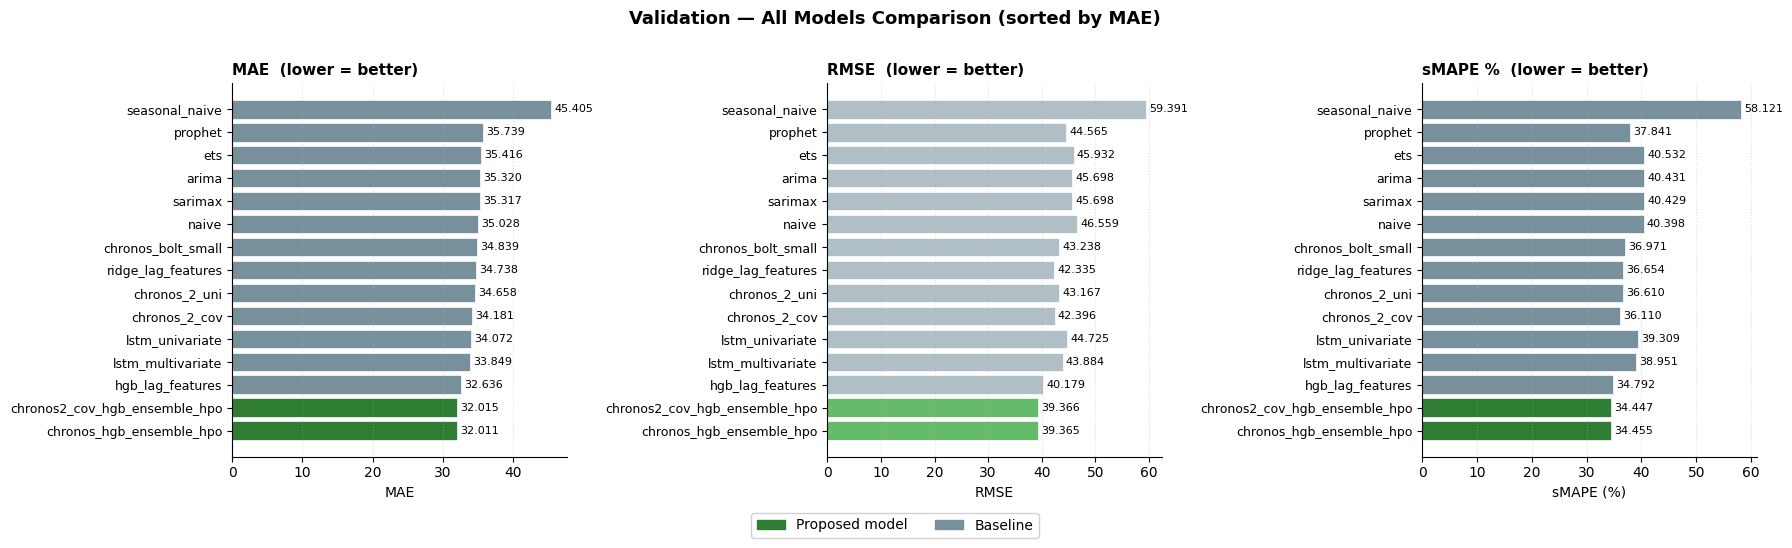

In [29]:
# ── Visual comparison: all models in val_table, sorted by val_MAE ─────────────

import matplotlib.patches as mpatches

_PROPOSED = {
    "chronos2_cov_hgb_ensemble_hpo",
    "chronos_hgb_ensemble_hpo",
}

_vt = val_table.copy().sort_values("val_MAE", ascending=True).reset_index(drop=True)
labels  = _vt["model"].tolist()
mae_v   = _vt["val_MAE"].tolist()
rmse_v  = _vt["val_RMSE"].tolist()
smape_v = _vt["val_sMAPE"].tolist()

colors_mae  = ["#2e7d32" if m in _PROPOSED else "#78909c" for m in labels]
colors_rmse = ["#66bb6a" if m in _PROPOSED else "#b0bec5" for m in labels]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Validation — All Models Comparison (sorted by MAE)", fontsize=13,
             fontweight="bold", y=1.01)

y_pos = np.arange(len(labels))

for ax, vals, cols, title, xlabel in [
    (axes[0], mae_v,   colors_mae,  "MAE  (lower = better)",   "MAE"),
    (axes[1], rmse_v,  colors_rmse, "RMSE  (lower = better)",  "RMSE"),
    (axes[2], smape_v, colors_mae,  "sMAPE %  (lower = better)","sMAPE (%)"),
]:

    bars = ax.barh(y_pos, vals, color=cols, edgecolor="white", linewidth=0.5)
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(v + max(vals) * 0.01, bar.get_y() + bar.get_height() / 2,
                    f"{v:.3f}", va="center", fontsize=8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight="bold", loc="left")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", linestyle=":", alpha=0.4)
    ax.set_xlim(left=0)
legend_patches = [
    mpatches.Patch(color="#2e7d32", label="Proposed model"),
    mpatches.Patch(color="#78909c", label="Baseline"),
]
fig.legend(handles=legend_patches, loc="lower center", ncol=2,
           fontsize=10, framealpha=0.9, bbox_to_anchor=(0.5, -0.06))

plt.tight_layout()
plt.show()

## Phase 7 — Feature Importance: Tuned Tabular Ensemble Component


Computing permutation importance on val set (n_repeats=10) ...
Feature Importance — HGB component of Chronos-2+HGB (HPO)
  HPO (Optuna) |  alpha* (Chronos weight): 0.396


,feature,importance,std
0,Inventory Level,0.248914,0.008564
1,Promotion,0.111329,0.004045
2,Epidemic,0.095250,0.003620
3,Price,0.030040,0.001570
4,dayofyear,0.007569,0.000669
5,Competitor Pricing,0.006053,0.000730
6,roll_mean_28,0.002752,0.000920
7,lag_2,0.002291,0.000347
8,roll_mean_14,0.002005,0.000751
9,roll_mean_7,0.001188,0.000624


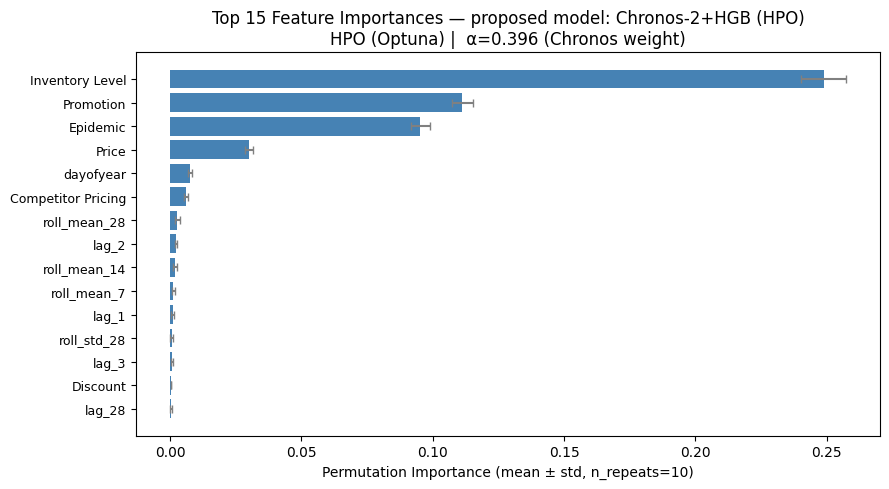

In [30]:
# === Feature Importance: HGB component of Chronos-2+HGB (HPO) ===
# Note: HistGradientBoostingRegressor does NOT expose .feature_importances_
# → use permutation importance on val set instead (model-agnostic, reliable)

from sklearn.inspection import permutation_importance as _perm_imp

if HPO_ENSEMBLE_AVAILABLE and _best_hgb_params and "hpo" in _best_hgb_params:
    _best_key = "hpo"
    _best_params, _best_hgb, _best_alpha = _best_hgb_params[_best_key]

    print(f"Computing permutation importance on val set (n_repeats=10) ...")
    _perm = _perm_imp(_best_hgb, X_val, y_val, n_repeats=10,
                      random_state=RANDOM_SEED, n_jobs=-1)
    imp_df_hpo = pd.DataFrame({
        'feature':    feature_cols,
        'importance': _perm.importances_mean,
        'std':        _perm.importances_std,
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    print(f"Feature Importance — HGB component of Chronos-2+HGB (HPO)")
    print(f"  HPO (Optuna) |  alpha* (Chronos weight): {_best_alpha:.3f}")
    display(imp_df_hpo.head(15))

    _top_fi = imp_df_hpo.head(15).iloc[::-1]
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(_top_fi['feature'], _top_fi['importance'],
            xerr=_top_fi['std'], color='steelblue', ecolor='gray', capsize=3)
    ax.set_xlabel('Permutation Importance (mean ± std, n_repeats=10)')
    ax.set_title(
        f'Top 15 Feature Importances — proposed model: Chronos-2+HGB (HPO)\n'
        f'HPO (Optuna) |  α={_best_alpha:.3f} (Chronos weight)'
    )
    ax.tick_params(axis='y', labelsize=9)
    plt.tight_layout()
    plt.show()

else:
    imp_df_hpo = pd.DataFrame(columns=['feature', 'importance'])
    print("HPO ensemble not available — feature importance skipped.")


## Phase 9 — Multi-Dimensional Error Analysis (Proposed Ensemble)

Systematic residual breakdown of the proposed model across five operational dimensions, benchmarked against persistence baselines:

| Panel | Diagnostic Dimension | Core Analytical Question |
|---|---|---|
| 1 | **Temporal Progression** | Does forecast error degrade over the horizon steps? Is concept drift evident? |
| 2 | **Day-of-Week Effect** | Are residual errors amplified during weekend consumer shopping surges? |
| 3 | **Peak vs. Trough Regimes** | How does accuracy vary across extreme high-demand vs. baseline low-demand days? |
| 4 | **Promotional Response** | Are discount and promotion-induced demand spikes accurately captured? |
| 5 | **Per-Series Distribution** | Which specific store-product categories exhibit the largest residual variance? |

Top-3 worst series (highest val MAE):
  Store=S002  Product=P0004  MAE=41.5500
  Store=S005  Product=P0009  MAE=39.4559
  Store=S003  Product=P0015  MAE=39.2153


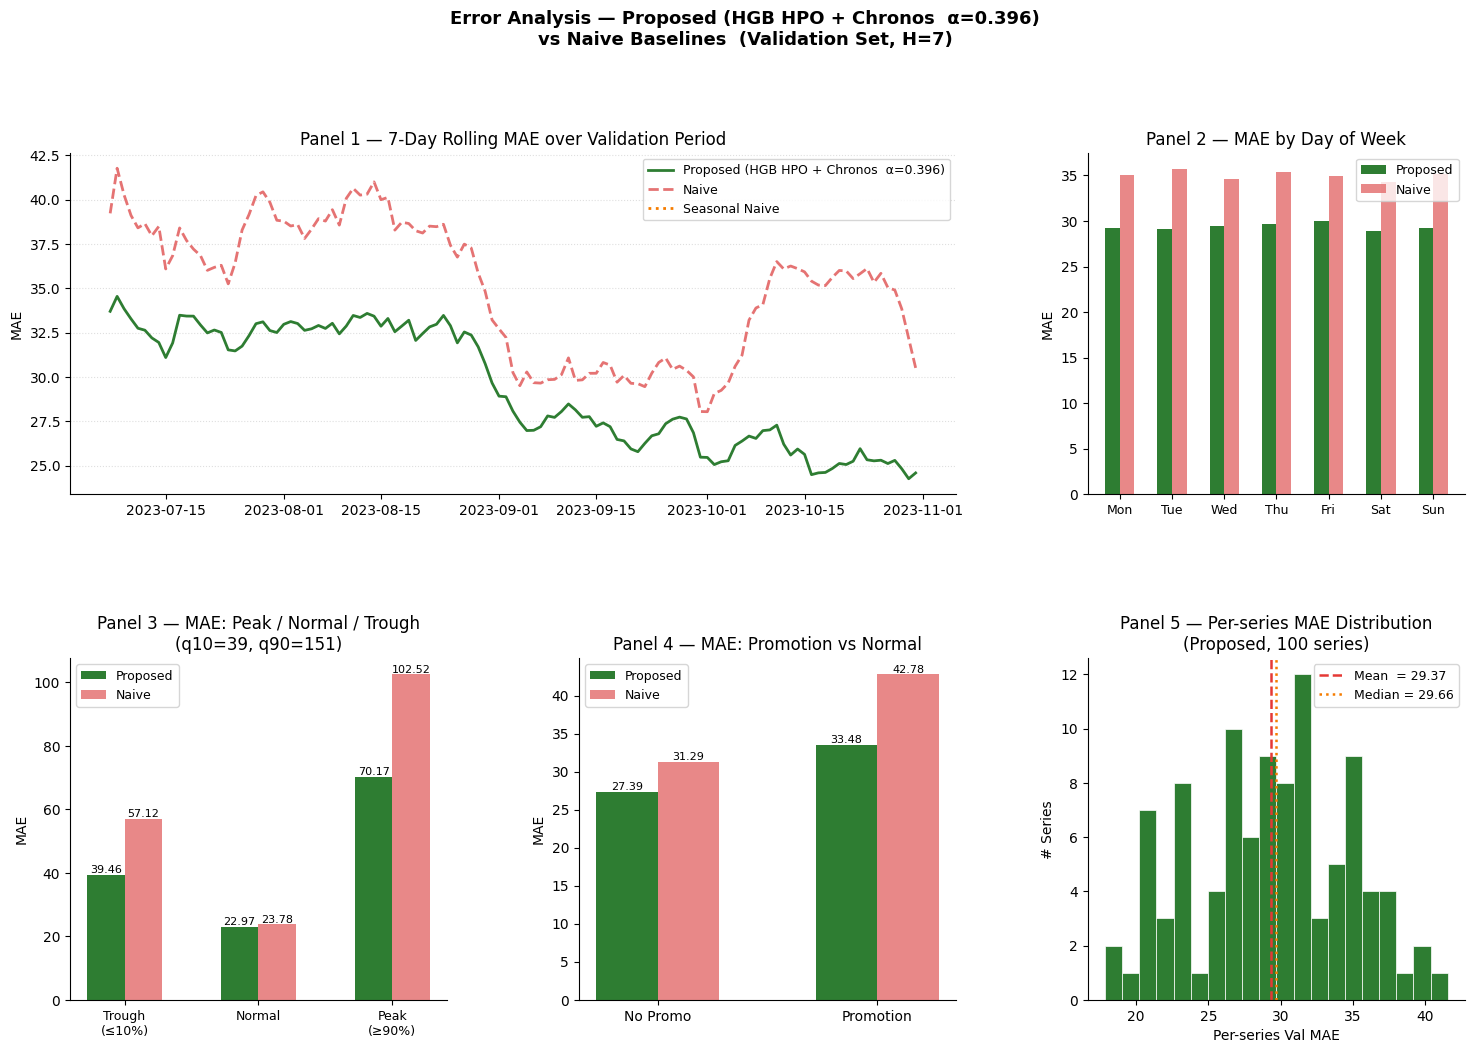


=== Error Analysis Summary — Proposed (HGB HPO + Chronos  α=0.396) ===
Overall val MAE:           29.3665
Naive val MAE:             35.0277
Peak demand MAE   (≥90%):  70.1732
Normal demand MAE:         22.9747
Trough demand MAE (≤10%):  39.4605
Promotion=1 MAE:           33.4773
Promotion=0 MAE:           27.3854


In [31]:
# === Error Analysis — Proposed Model (Chronos-2+HGB + HPO) ===
from matplotlib.gridspec import GridSpec

# ── HPO HGB component for per-timestep analysis ─────────────────────────────
if HPO_ENSEMBLE_AVAILABLE and _best_hgb_params and "hpo" in _best_hgb_params:
    _, _ea_hgb, _ea_alpha = _best_hgb_params["hpo"]
    val_pred_proposed = np.clip(_ea_hgb.predict(X_val), 0, None)
    _model_label = f"Proposed (HGB HPO + Chronos  α={_ea_alpha:.3f})"
else:
    val_pred_proposed = val_pred_hgb
    _model_label = "HGB (fallback — HPO not available)"

# ── Build error dataframe (aligned to val_feat / X_val) ──────────────────────
# Compute abserr_snaive BEFORE reset_index so val_df label alignment is preserved
_vf = val_feat.copy()
_vf["Date"]            = pd.to_datetime(_vf["Date"])
_vf["y_true"]          = y_val.values
_vf["abserr_proposed"] = np.abs(val_pred_proposed - _vf["y_true"])
_vf["abserr_naive"]    = np.abs(last_train_value  - _vf["y_true"])

# val_pred_snaive is positionally aligned to val_df; reindex via original index labels
_snaive_s = pd.Series(val_pred_snaive, index=val_df.index)
_vf["abserr_snaive"] = np.abs(_snaive_s.reindex(_vf.index).values - _vf["y_true"].values)

_vf = _vf.reset_index(drop=True)

# ── Demand segments ───────────────────────────────────────────────────────────
q10, q90 = _vf["y_true"].quantile(0.10), _vf["y_true"].quantile(0.90)
_vf["segment"] = "Normal"
_vf.loc[_vf["y_true"] >= q90, "segment"] = "Peak\n(≥90%)"
_vf.loc[_vf["y_true"] <= q10, "segment"] = "Trough\n(≤10%)"
_seg_order = ["Trough\n(≤10%)", "Normal", "Peak\n(≥90%)"]

# ── Figure layout: 2 rows × 3 cols ───────────────────────────────────────────
fig = plt.figure(figsize=(18, 11))
fig.suptitle(f"Error Analysis — {_model_label}\nvs Naive Baselines  (Validation Set, H=7)",
             fontsize=13, fontweight="bold", y=1.01)
gs = GridSpec(2, 3, figure=fig, hspace=0.48, wspace=0.35)
ax1 = fig.add_subplot(gs[0, :2])   # wide: error over time
ax2 = fig.add_subplot(gs[0, 2])    # day-of-week
ax3 = fig.add_subplot(gs[1, 0])    # peak vs trough
ax4 = fig.add_subplot(gs[1, 1])    # promotion
ax5 = fig.add_subplot(gs[1, 2])    # per-series distribution

_C_PROP  = "#2e7d32"
_C_NAIVE = "#e57373"
_C_SN    = "#f57c00"
_W = 0.28

# ── Panel 1: Rolling error over time ─────────────────────────────────────────
_daily = _vf.groupby("Date")[["abserr_proposed", "abserr_naive", "abserr_snaive"]].mean()
for col, label, color, ls in [
    ("abserr_proposed", _model_label,    _C_PROP,  "-"),
    ("abserr_naive",    "Naive",         _C_NAIVE, "--"),
    ("abserr_snaive",   "Seasonal Naive",_C_SN,    ":"),
]:
    ax1.plot(_daily.index, _daily[col].rolling(7).mean(),
             label=label, color=color, linestyle=ls, linewidth=2)
ax1.set_title("Panel 1 — 7-Day Rolling MAE over Validation Period")
ax1.set_ylabel("MAE")
ax1.legend(fontsize=9)
ax1.spines["top"].set_visible(False); ax1.spines["right"].set_visible(False)
ax1.grid(axis="y", linestyle=":", alpha=0.4)

# ── Panel 2: MAE by Day of Week ──────────────────────────────────────────────
_dow = _vf.groupby("dayofweek")[["abserr_proposed", "abserr_naive"]].mean()
_dow.index = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
x = np.arange(len(_dow))
ax2.bar(x - _W/2, _dow["abserr_proposed"], _W, label="Proposed", color=_C_PROP)
ax2.bar(x + _W/2, _dow["abserr_naive"],    _W, label="Naive",    color=_C_NAIVE, alpha=0.85)
ax2.set_xticks(x); ax2.set_xticklabels(_dow.index, fontsize=9)
ax2.set_title("Panel 2 — MAE by Day of Week")
ax2.set_ylabel("MAE")
ax2.legend(fontsize=9)
ax2.spines["top"].set_visible(False); ax2.spines["right"].set_visible(False)

# ── Panel 3: Peak vs Trough ──────────────────────────────────────────────────
_seg = _vf.groupby("segment")[["abserr_proposed", "abserr_naive"]].mean().reindex(_seg_order)
x3 = np.arange(len(_seg_order))
ax3.bar(x3 - _W/2, _seg["abserr_proposed"], _W, label="Proposed", color=_C_PROP)
ax3.bar(x3 + _W/2, _seg["abserr_naive"],    _W, label="Naive",    color=_C_NAIVE, alpha=0.85)
ax3.set_xticks(x3); ax3.set_xticklabels(_seg_order, fontsize=9)
ax3.set_title(f"Panel 3 — MAE: Peak / Normal / Trough\n(q10={q10:.0f}, q90={q90:.0f})")
ax3.set_ylabel("MAE")
ax3.legend(fontsize=9)
for p in ax3.patches:
    ax3.annotate(f"{p.get_height():.2f}",
                 (p.get_x() + p.get_width()/2, p.get_height()),
                 ha="center", va="bottom", fontsize=8)
ax3.spines["top"].set_visible(False); ax3.spines["right"].set_visible(False)

# ── Panel 4: Promotion vs Non-promotion ──────────────────────────────────────
if "Promotion" in _vf.columns:
    _promo = _vf.groupby("Promotion")[["abserr_proposed", "abserr_naive"]].mean()
    _promo.index = ["No Promo", "Promotion"]
    x4 = np.arange(2)
    ax4.bar(x4 - _W/2, _promo["abserr_proposed"], _W, label="Proposed", color=_C_PROP)
    ax4.bar(x4 + _W/2, _promo["abserr_naive"],    _W, label="Naive",    color=_C_NAIVE, alpha=0.85)
    ax4.set_xticks(x4); ax4.set_xticklabels(_promo.index, fontsize=10)
    for p in ax4.patches:
        ax4.annotate(f"{p.get_height():.2f}",
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha="center", va="bottom", fontsize=8)
    ax4.legend(fontsize=9)
else:
    ax4.text(0.5, 0.5, "Promotion column\nnot in features",
             ha="center", va="center", transform=ax4.transAxes, fontsize=10, color="#9e9e9e")
ax4.set_title("Panel 4 — MAE: Promotion vs Normal")
ax4.set_ylabel("MAE")
ax4.spines["top"].set_visible(False); ax4.spines["right"].set_visible(False)

# ── Panel 5: Per-series MAE distribution ─────────────────────────────────────
if "Store ID" in _vf.columns and "Product ID" in _vf.columns:
    _series_mae = _vf.groupby(["Store ID", "Product ID"])["abserr_proposed"].mean()
    ax5.hist(_series_mae, bins=20, color=_C_PROP, edgecolor="white", linewidth=0.5)
    ax5.axvline(_series_mae.mean(),   color="#e53935", linestyle="--", linewidth=1.8,
                label=f"Mean  = {_series_mae.mean():.2f}")
    ax5.axvline(_series_mae.median(), color=_C_SN,    linestyle=":",  linewidth=1.8,
                label=f"Median = {_series_mae.median():.2f}")
    ax5.set_xlabel("Per-series Val MAE")
    ax5.set_ylabel("# Series")
    ax5.legend(fontsize=9)
    # Annotate worst series
    _worst = _series_mae.nlargest(3)
    print(f"Top-3 worst series (highest val MAE):")
    for (st, pr), v in _worst.items():
        print(f"  Store={st}  Product={pr}  MAE={v:.4f}")
else:
    ax5.text(0.5, 0.5, "Series info not available", ha="center", va="center",
             transform=ax5.transAxes, fontsize=10, color="#9e9e9e")
ax5.set_title("Panel 5 — Per-series MAE Distribution\n(Proposed, 100 series)")
ax5.spines["top"].set_visible(False); ax5.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\n=== Error Analysis Summary — {_model_label} ===")
print(f"Overall val MAE:           {_vf['abserr_proposed'].mean():.4f}")
print(f"Naive val MAE:             {_vf['abserr_naive'].mean():.4f}")
_peak_mae   = _vf[_vf["segment"] == "Peak\n(≥90%)"]["abserr_proposed"].mean()
_trough_mae = _vf[_vf["segment"] == "Trough\n(≤10%)"]["abserr_proposed"].mean()
_normal_mae = _vf[_vf["segment"] == "Normal"]["abserr_proposed"].mean()
print(f"Peak demand MAE   (≥90%):  {_peak_mae:.4f}")
print(f"Normal demand MAE:         {_normal_mae:.4f}")
print(f"Trough demand MAE (≤10%):  {_trough_mae:.4f}")
if "Promotion" in _vf.columns:
    print(f"Promotion=1 MAE:           {_vf[_vf['Promotion']==1]['abserr_proposed'].mean():.4f}")
    print(f"Promotion=0 MAE:           {_vf[_vf['Promotion']==0]['abserr_proposed'].mean():.4f}")

  val (Bolt raw dict): 100 series accepted, 0 skipped
Could not reconstruct Chronos-Bolt from raw dict: NumPy boolean array indexing assignment cannot assign 7 input values to the 123 output values where the mask is true
Chronos-Bolt flat predictions unavailable — showing HGB vs Proposed only.


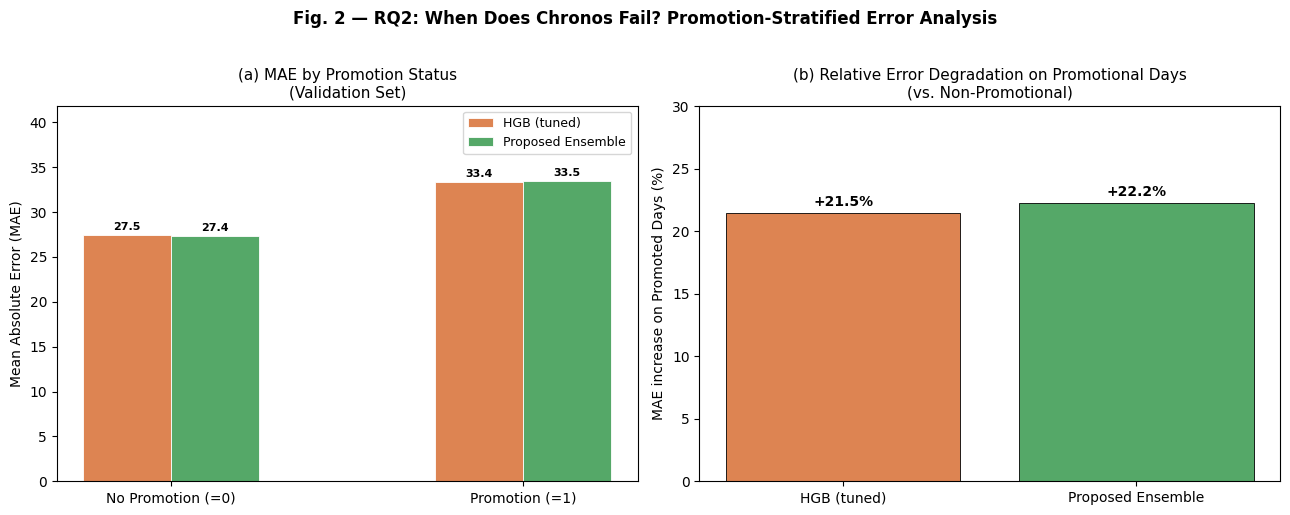

Saved: outputs/fig2_promotion_error_analysis.png

── Promotion-stratified MAE ──
           HGB (tuned)  Proposed Ensemble
Promotion                                
0                27.49              27.39
1                33.39              33.48

── Relative degradation on promoted days ──
  HGB (tuned): +21.5%
  Proposed Ensemble: +22.2%


In [32]:

# === Fig. 2 — Promotion-Stratified MAE: Chronos-Bolt vs HGB vs Proposed (RQ2) ===
# Requires: _vf (Phase 9), val_pred_hgb, val_df, _chronos_bolt_raw_dict or chronos_val_records

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    # ── 1. Build base dataframe from _vf (Phase 9) ────────────────────────────
    assert "_vf" in dir() or "_vf" in globals(), "_vf not found; run Phase 9 first"
    _f2 = _vf[["y_true", "Promotion", "Date"]].copy() if "Date" in _vf.columns else _vf[["y_true", "Promotion"]].copy()

    # ── 2. HGB absolute errors ─────────────────────────────────────────────────
    assert "val_pred_hgb" in globals(), "val_pred_hgb not found"
    _f2["abserr_hgb"] = np.abs(np.asarray(val_pred_hgb) - _f2["y_true"].values)

    # ── 3. Proposed ensemble errors (already in _vf) ───────────────────────────
    # abserr_proposed is set by Phase 9

    # ── 4. Chronos-Bolt: reconstruct flat predictions from raw dict ────────────
    _chronos_bolt_preds_flat = None
    if globals().get("_chronos_bolt_raw_dict") is not None:
        try:
            _bolt_val_raw = _chronos_bolt_raw_dict(TRAIN_END, "val")   # {(store,product): array(H)}
            # _vf has multi-index or reset; align via val_df index
            _val_df_reset = val_df.reset_index(drop=True).copy()
            _bolt_flat = np.full(len(_val_df_reset), np.nan)
            for (sid, pid), preds in _bolt_val_raw.items():
                mask = (_val_df_reset["Store ID"] == sid) & (_val_df_reset["Product ID"] == pid)
                _bolt_flat[mask] = preds[:mask.sum()]
            if not np.isnan(_bolt_flat).all():
                _chronos_bolt_preds_flat = _bolt_flat
                print("Chronos-Bolt predictions reconstructed from raw dict.")
        except Exception as _eb:
            print(f"Could not reconstruct Chronos-Bolt from raw dict: {_eb}")

    if _chronos_bolt_preds_flat is None:
        print("Chronos-Bolt flat predictions unavailable — showing HGB vs Proposed only.")

    # ── 5. Compute promotion-stratified MAE ───────────────────────────────────
    _f2["abserr_proposed"] = _vf["abserr_proposed"].values
    if _chronos_bolt_preds_flat is not None:
        _f2["abserr_chronos"] = np.abs(_chronos_bolt_preds_flat - _f2["y_true"].values)

    _promo = _f2.groupby("Promotion")

    _model_cols   = ["abserr_hgb", "abserr_proposed"]
    _model_labels = ["HGB (tuned)", "Proposed Ensemble"]
    _colors       = ["#dd8452", "#55a868"]
    if "abserr_chronos" in _f2.columns:
        _model_cols   = ["abserr_chronos"] + _model_cols
        _model_labels = ["Chronos-Bolt"] + _model_labels
        _colors       = ["#4c72b0"] + _colors

    _promo_mae = _promo[_model_cols].mean()

    # ── 6. Plot ────────────────────────────────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    x  = np.arange(2)
    w  = 0.25
    xlabels = ["No Promotion (=0)", "Promotion (=1)"]

    for j, (col, label, c) in enumerate(zip(_model_cols, _model_labels, _colors)):
        vals = [_promo_mae.loc[0, col], _promo_mae.loc[1, col]]
        offset = (j - (len(_model_cols) - 1) / 2) * w
        bars = ax1.bar(x + offset, vals, w, label=label, color=c, edgecolor="white", linewidth=0.6)
        for bar, v in zip(bars, vals):
            ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                     f"{v:.1f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

    ax1.set_xticks(x)
    ax1.set_xticklabels(xlabels, fontsize=10)
    ax1.set_ylabel("Mean Absolute Error (MAE)", fontsize=10)
    ax1.set_title("(a) MAE by Promotion Status\n(Validation Set)", fontsize=11)
    ax1.legend(fontsize=9)
    ax1.set_ylim(0, _promo_mae.max().max() * 1.25)

    # Panel 2: relative degradation (%)
    _degradation = [
        (_promo_mae.loc[1, c] - _promo_mae.loc[0, c]) / _promo_mae.loc[0, c] * 100
        for c in _model_cols
    ]
    bars2 = ax2.bar(_model_labels, _degradation, color=_colors, edgecolor="black", linewidth=0.6)
    for bar, v in zip(bars2, _degradation):
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f"+{v:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax2.set_ylabel("MAE increase on Promoted Days (%)", fontsize=10)
    ax2.set_title("(b) Relative Error Degradation on Promotional Days\n(vs. Non-Promotional)", fontsize=11)
    ax2.set_ylim(0, max(_degradation) * 1.35)

    plt.suptitle("Fig. 2 — RQ2: When Does Chronos Fail? Promotion-Stratified Error Analysis",
                 fontsize=12, y=1.02, fontweight="bold")
    plt.tight_layout()

    _out = os.path.join(OUTPUT_DIR, "fig2_promotion_error_analysis.png")
    plt.savefig(_out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {_out}")

    print("\n── Promotion-stratified MAE ──")
    print(_promo_mae[_model_cols].rename(columns=dict(zip(_model_cols, _model_labels))).round(2))
    print("\n── Relative degradation on promoted days ──")
    for lbl, d in zip(_model_labels, _degradation):
        print(f"  {lbl}: +{d:.1f}%")

except Exception as _e:
    print(f"Fig. 2 skipped: {type(_e).__name__}: {_e}")


## Phase 10 — Systematic Ablation Study (Proposed Ensemble)

Investigates individual component and feature contributions by systematically **ablating or isolating constituent modules**. All ablation experiments are conducted on the standardized validation set ($H=7$, strictly without lookahead leakage).

| Ablation Variant | Configuration / Modification | Research Question Investigated |
|---|---|---|
| **B1: Foundation Only** | $\alpha = 1.0$ (HGB weight $= 0$) | Is the tabular GBDT component necessary? |
| **B2: Tabular GBDT Only** | $\alpha = 0.0$ (Foundation weight $= 0$) | Does the pretrained foundation model provide genuine additive value? |
| **B3: Unoptimized Ensemble (No HPO)** | Default HGB parameters, post-hoc $\alpha^*$ | What is the quantitative gain from joint Optuna hyperparameter optimization? |
| **B4: No Autoregressive Lags** | Remove all `lag_{1,2,3,7,14,28}` features | How critical is localized short-term autoregressive memory? |
| **B5: No Calendar Indicators** | Remove `dayofweek`, `month`, `dayofyear` | Can tree ensembles infer calendar periodicity solely from autoregressive lags? |
| **B6: No Exogenous Signals** | Remove `Price`, `Discount`, `Promotion`, `Epidemic` | To what degree do exogenous economic signals improve forecast fidelity? |

Feature groups:
  Lag (6): ['lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_28']
  Rolling (6): ['roll_mean_7', 'roll_std_7', 'roll_mean_14', 'roll_std_14', 'roll_mean_28', 'roll_std_28']
  Calendar (3): ['dayofweek', 'month', 'dayofyear']
  Exogenous (6): ['Inventory Level', 'Price', 'Discount', 'Promotion', 'Competitor Pricing', 'Epidemic']
  [val] Chronos-2 proposed: target=['Units Sold'], past_cov=17, future_cov=['dayofweek', 'month', 'dayofyear', 'Price', 'Discount'], 100 series, 0 skipped

Chronos-2 val preds: 100 series
  val (Bolt raw dict): 100 series accepted, 0 skipped
Chronos-Bolt val preds: 100 series

Ablation suite: Chronos-2 (cov) + HGB (HPO)
  FULL  MAE=32.0152  RMSE=39.3658  sMAPE=34.4468
  B1    MAE=34.1808  RMSE=42.3959  sMAPE=36.1095
  B2    MAE=32.4805  RMSE=39.8798  sMAPE=34.5634
  B3    MAE=32.3634  RMSE=39.8305  sMAPE=34.7279
  B4    MAE=32.1523  RMSE=39.4974  sMAPE=34.5729
  B5    MAE=32.0802  RMSE=39.4609  sMAPE=34.5169
  B6    MAE=34.6231  RMSE=43.139  sM

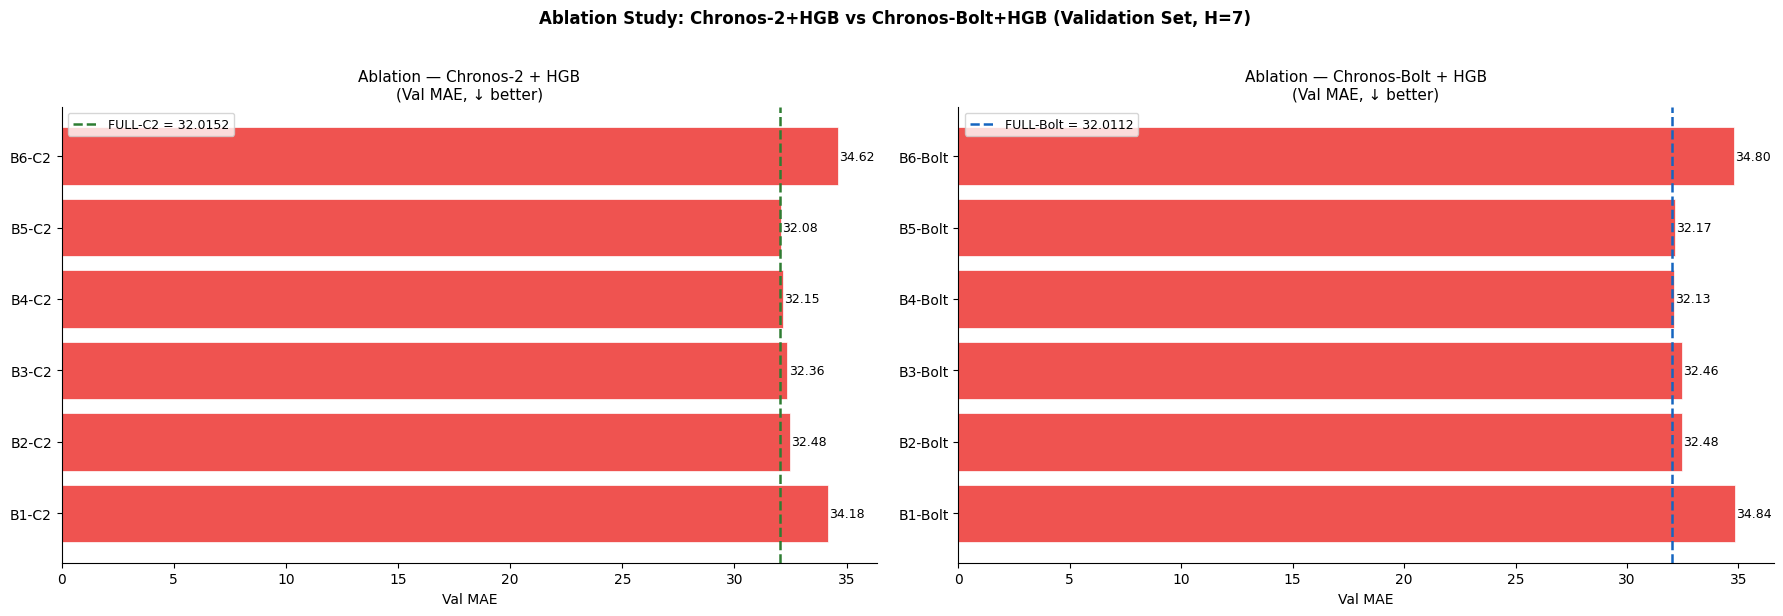

Saved: outputs/ablation_proposed_model.png
Saved: outputs/ablation_proposed_b1b6_summary.csv (14 rows)


In [33]:
# === Ablation Study — Both Proposed Variants: Chronos-2+HGB and Bolt+HGB ===
# Runs full B1–B6 ablation independently for each variant.
# Requires: CHRONOS2_AVAILABLE, `_chronos_raw`, _chronos_bolt_raw_dict, _best_hgb_params
# All evaluations on validation set via (H=7, no oracle lags)

from sklearn.ensemble import HistGradientBoostingRegressor as _HGB

# ── Feature groups ────────────────────────────────────────────────────────────
_LAG_COLS      = [c for c in feature_cols if c.startswith("lag_")]
_ROLL_COLS     = [c for c in feature_cols if c.startswith("roll_")]
_CALENDAR_COLS = [c for c in feature_cols if c in ("dayofweek", "month", "dayofyear")]
_EXOG_COLS     = [c for c in feature_cols if c not in _LAG_COLS + _ROLL_COLS + _CALENDAR_COLS]

print("Feature groups:")
print(f"  Lag ({len(_LAG_COLS)}): {_LAG_COLS}")
print(f"  Rolling ({len(_ROLL_COLS)}): {_ROLL_COLS}")
print(f"  Calendar ({len(_CALENDAR_COLS)}): {_CALENDAR_COLS}")
print(f"  Exogenous ({len(_EXOG_COLS)}): {_EXOG_COLS}")

# ── Guard ─────────────────────────────────────────────────────────────────────
if not (CHRONOS2_AVAILABLE and globals().get("_chronos_raw") is not None):
    print("Chronos-2 not available — ablation skipped.")
    _ablation_records = []
else:
    # ── Load Chronos val predictions ─────────────────────────────────────────
    _c2_val_abl = _chronos_raw(context_end=TRAIN_END, prefix='val')
    print(f"\nChronos-2 val preds: {len(_c2_val_abl)} series")

    _bolt_val_abl = None
    if globals().get("_chronos_bolt_raw_dict") is not None:
        try:
            _bolt_val_abl = _chronos_bolt_raw_dict(TRAIN_END, "val")
            print(f"Chronos-Bolt val preds: {len(_bolt_val_abl)} series")
        except Exception as _eb:
            print(f"Chronos-Bolt val preds unavailable: {_eb}")

    # ── Best HPO params (shared HGB component) ────────────────────────────────
    _best_key = (
        _hpo_best_strategy_key
        if (_hpo_best_strategy_key and _hpo_best_strategy_key in _best_hgb_params)
        else ("hpo" if _best_hgb_params and "hpo" in _best_hgb_params else None)
    )
    _best_bp, _, _best_alpha = _best_hgb_params[_best_key] if _best_key else ({}, None, 0.5)
    _best_hgb_p = {k: v for k, v in _best_bp.items() if k != "alpha"}
    _best_hgb_p["random_state"] = RANDOM_SEED
    _default_hgb_p = {"max_depth": 5, "learning_rate": 0.05, "random_state": RANDOM_SEED}

    def _abl_eval(ablation_id, label, feat_subset, alpha_val, chronos_preds, hgb_params=None):
        """Fit HGB on feat_subset, blend with chronos_preds at alpha_val, eval on val."""
        _p = hgb_params or _default_hgb_p
        _m = _HGB(**_p)
        _m.fit(train_feat[feat_subset], train_feat["Units Sold"])
        _h_val = build_hgb_horizon_predictions(_m, TRAIN_END, df, feat_subset)
        _met, _ = _blend_eval(chronos_preds, _h_val, alpha_val, 'val')
        return {
            "ablation": ablation_id, "label": label,
            "alpha": round(alpha_val, 3), "n_features": len(feat_subset),
            "val_MAE":   round(_met["val_MAE"],   4),
            "val_RMSE":  round(_met["val_RMSE"],  4),
            "val_sMAPE": round(_met["val_sMAPE"], 4),
        }

    def _run_ablations(tag, chronos_preds, full_metrics, full_label):
        """Run full B1–B6 suite for one Chronos variant."""
        print(f"\n{'='*60}")
        print(f"Ablation suite: {full_label}")
        print(f"{'='*60}")

        # FULL reference
        _full = {
            "ablation": f"FULL-{tag}", "label": full_label,
            "alpha": round(_best_alpha, 3), "n_features": len(feature_cols),
            "val_MAE":   round(full_metrics.get("val_MAE",   float("nan")), 4),
            "val_RMSE":  round(full_metrics.get("val_RMSE",  float("nan")), 4),
            "val_sMAPE": round(full_metrics.get("val_sMAPE", float("nan")), 4),
        }
        print(f"  FULL  MAE={_full['val_MAE']}  RMSE={_full['val_RMSE']}  sMAPE={_full['val_sMAPE']}")

        # B1: Chronos Only
        _h_zeros = {k: np.zeros(HORIZON_DAYS) for k in chronos_preds}
        _b1m, _ = _blend_eval(chronos_preds, _h_zeros, 1.0, 'val')
        _b1 = {"ablation": f"B1-{tag}", "label": f"{tag} Only (α=1)", "alpha": 1.0, "n_features": 0,
               "val_MAE": round(_b1m["val_MAE"], 4), "val_RMSE": round(_b1m["val_RMSE"], 4),
               "val_sMAPE": round(_b1m["val_sMAPE"], 4)}
        print(f"  B1    MAE={_b1['val_MAE']}  RMSE={_b1['val_RMSE']}  sMAPE={_b1['val_sMAPE']}")

        # B2: HGB Only
        _b2 = _abl_eval(f"B2-{tag}", "HGB Only (α=0)", feature_cols, 0.0, chronos_preds, _best_hgb_p)
        print(f"  B2    MAE={_b2['val_MAE']}  RMSE={_b2['val_RMSE']}  sMAPE={_b2['val_sMAPE']}")

        # B3: No HPO
        _b3 = _abl_eval(f"B3-{tag}", "No HPO (default, α=0.5)", feature_cols, 0.5, chronos_preds, _default_hgb_p)
        print(f"  B3    MAE={_b3['val_MAE']}  RMSE={_b3['val_RMSE']}  sMAPE={_b3['val_sMAPE']}")

        # B4: No Lag
        _feat_no_lag = [c for c in feature_cols if c not in _LAG_COLS]
        _b4 = _abl_eval(f"B4-{tag}", f"No Lag (–{len(_LAG_COLS)})", _feat_no_lag, _best_alpha, chronos_preds, _best_hgb_p)
        print(f"  B4    MAE={_b4['val_MAE']}  RMSE={_b4['val_RMSE']}  sMAPE={_b4['val_sMAPE']}")

        # B5: No Calendar
        _feat_no_cal = [c for c in feature_cols if c not in _CALENDAR_COLS]
        _b5 = _abl_eval(f"B5-{tag}", f"No Calendar (–{len(_CALENDAR_COLS)})", _feat_no_cal, _best_alpha, chronos_preds, _best_hgb_p)
        print(f"  B5    MAE={_b5['val_MAE']}  RMSE={_b5['val_RMSE']}  sMAPE={_b5['val_sMAPE']}")

        # B6: No Exogenous
        _feat_no_exog = [c for c in feature_cols if c not in _EXOG_COLS]
        _b6 = _abl_eval(f"B6-{tag}", f"No Exogenous (–{len(_EXOG_COLS)})", _feat_no_exog, _best_alpha, chronos_preds, _best_hgb_p)
        print(f"  B6    MAE={_b6['val_MAE']}  RMSE={_b6['val_RMSE']}  sMAPE={_b6['val_sMAPE']}")

        rows = [_full, _b1, _b2, _b3, _b4, _b5, _b6]
        _df = pd.DataFrame(rows)
        _df["ΔMAE"]  = (_df["val_MAE"]  - _full["val_MAE"]).round(4)
        _df["Δ%MAE"] = ((_df["val_MAE"] / _full["val_MAE"] - 1) * 100).round(2)
        _df.loc[_df["ablation"] == f"FULL-{tag}", ["ΔMAE", "Δ%MAE"]] = 0.0
        return _df

    # ── Run for Chronos-2 + HGB ───────────────────────────────────────────────
    abl_c2_df = _run_ablations(
        "C2", _c2_val_abl,
        ensemble_hpo_val_metrics,
        "Chronos-2 (cov) + HGB (HPO)"
    )

    # ── Run for Chronos-Bolt + HGB ────────────────────────────────────────────
    abl_bolt_df = None
    if _bolt_val_abl is not None:
        abl_bolt_df = _run_ablations(
            "Bolt", _bolt_val_abl,
            chronos_hgb_ensemble_hpo_val_metrics,
            "Chronos-Bolt + HGB (HPO)"
        )
    else:
        print("\nSkipping Bolt ablation — val preds unavailable.")

    # ── Print summary tables ──────────────────────────────────────────────────
    print("\n" + "="*70)
    print("ABLATION SUMMARY — Chronos-2 (cov) + HGB (val set, H=7)")
    print("="*70)
    print(abl_c2_df[["ablation","label","alpha","n_features","val_MAE","val_RMSE","val_sMAPE","ΔMAE","Δ%MAE"]].to_string(index=False))

    if abl_bolt_df is not None:
        print("\n" + "="*70)
        print("ABLATION SUMMARY — Chronos-Bolt + HGB (val set, H=7)")
        print("="*70)
        print(abl_bolt_df[["ablation","label","alpha","n_features","val_MAE","val_RMSE","val_sMAPE","ΔMAE","Δ%MAE"]].to_string(index=False))

    # ── Visualization: side-by-side bar charts ────────────────────────────────
    _variants = [("C2", abl_c2_df, "#2e7d32", "Chronos-2 + HGB")]
    if abl_bolt_df is not None:
        _variants.append(("Bolt", abl_bolt_df, "#1565c0", "Chronos-Bolt + HGB"))

    _ncols = len(_variants)
    fig, axes = plt.subplots(1, _ncols, figsize=(9 * _ncols, 6), sharey=False)
    if _ncols == 1:
        axes = [axes]

    for ax, (tag, _df, color, title) in zip(axes, _variants):
        _full_row = _df[_df["ablation"] == f"FULL-{tag}"].iloc[0]
        _abl_rows = _df[_df["ablation"] != f"FULL-{tag}"]
        _vals   = _abl_rows["val_MAE"].values
        _labels = _abl_rows["ablation"].values
        _colors = ["#ef5350" if v > _full_row["val_MAE"] else "#66bb6a" for v in _vals]
        bars = ax.barh(_labels, _vals, color=_colors, edgecolor="white", linewidth=0.5)
        ax.axvline(_full_row["val_MAE"], color=color, linestyle="--", linewidth=1.8,
                   label=f"FULL-{tag} = {_full_row['val_MAE']:.4f}")
        for bar, v in zip(bars, _vals):
            ax.text(v + 0.05, bar.get_y() + bar.get_height()/2,
                    f"{v:.2f}", va="center", ha="left", fontsize=9)
        ax.set_title(f"Ablation — {title}\n(Val MAE, ↓ better)", fontsize=11)
        ax.set_xlabel("Val MAE")
        ax.legend(fontsize=9)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.suptitle("Ablation Study: Chronos-2+HGB vs Chronos-Bolt+HGB (Validation Set, H=7)",
                 fontsize=12, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "ablation_proposed_model.png"), dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: outputs/ablation_proposed_model.png")

    # ── Export ────────────────────────────────────────────────────────────────
    _all_abl = pd.concat([abl_c2_df] + ([abl_bolt_df] if abl_bolt_df is not None else []), ignore_index=True)
    _all_abl["horizon"] = HORIZON_DAYS
    _csv_path = os.path.join(OUTPUT_DIR, "ablation_proposed_b1b6_summary.csv")
    _all_abl.to_csv(_csv_path, index=False)
    _ablation_records = _all_abl.to_dict("records")
    print(f"Saved: {_csv_path} ({len(_all_abl)} rows)")

## Phase 11 — Final Test Evaluation & Grouped Performance

In [34]:
best_model_name = val_table.iloc[0]["model"]
print("Best validation model:", best_model_name)


Best validation model: chronos_hgb_ensemble_hpo


In [35]:
# Prepare test predictions consistently
last_train_val = df[df["Date"] < "2023-11-01"]["Units Sold"].iloc[-1]
test_pred_naive = np.repeat(last_train_val, len(test_df))
history_until_test = df[df["Date"] < "2023-11-01"]["Units Sold"].values
test_pred_snaive = seasonal_naive_predict(history_until_test, len(test_df), season_length=7)
# Refit ARIMA on train + val
trainval_df = df[df["Date"] < "2023-11-01"].copy()
arima_tv = ARIMA(
    trainval_df["Units Sold"],
    order=(2,1,2)
)
arima_tv_fit = arima_tv.fit()
test_pred_arima = arima_tv_fit.forecast(steps=len(test_df))
# Refit SARIMAX on train + val
sarimax_tv = SARIMAX(
    trainval_df["Units Sold"],
    order=(2,1,2),
    seasonal_order=(1,0,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarimax_tv_fit = sarimax_tv.fit(disp=False)
test_pred_sarimax = sarimax_tv_fit.forecast(steps=len(test_df))
# Refit ETS on train + val
ets_tv = ExponentialSmoothing(
    trainval_df["Units Sold"],
    trend="add",
    seasonal="add",
    seasonal_periods=7
).fit(optimized=True)
test_pred_ets = ets_tv.forecast(len(test_df))
# Prophet per-series evaluation on test split
prophet_test_records = []
prophet_test_scores = {'test_MAE': [], 'test_RMSE': [], 'test_sMAPE': []}
for (store, product), grp in df.groupby(['Store ID', 'Product ID']):
    s_ts = grp.set_index('Date')['Units Sold'].sort_index()
    s_ts.index = pd.to_datetime(s_ts.index)
    trainval_s = s_ts[s_ts.index <= VAL_END]
    test_s = s_ts[s_ts.index > VAL_END]
    if len(trainval_s) < 14 or len(test_s) < HORIZON_DAYS:
        continue
    try:
        y_pred = prophet_fn(trainval_s.index, trainval_s.values, len(test_s))
        y_true = test_s.values.astype(float)
        m = eval_forecast(y_true, y_pred, prefix='test', y_train=trainval_s.values)
    except Exception:
        continue
    for k in prophet_test_scores:
        prophet_test_scores[k].append(m[k])
    prophet_test_records.append({
        'store': store, 'product': product,
        **{k: round(float(m[k]), 4) for k in m}
    })
prophet_test_metrics = {k: float(np.nanmean(v)) for k, v in prophet_test_scores.items()}
print(f'Prophet test: {len(prophet_test_records)} series | metrics: {prophet_test_metrics}')
# Refit LSTM-univariate on train + val
try:
    import torch
    import torch.nn as nn
    torch.manual_seed(RANDOM_SEED)
    class LSTMUni(nn.Module):
        def __init__(self, hidden_size=64):
            super().__init__()
            self.lstm = nn.LSTM(input_size=1, hidden_size=hidden_size, batch_first=True)
            self.dropout = nn.Dropout(0.2)
            self.fc = nn.Linear(hidden_size, 1)
        def forward(self, x):
            out, _ = self.lstm(x)
            out = self.dropout(out[:, -1, :])
            return self.fc(out).squeeze(-1)
    # Daily aggregate: rolling daily sequence strictly preserving chronological order
    ts_daily_tv = df.groupby("Date")["Units Sold"].mean().sort_index()
    ts_daily_tv.index = pd.to_datetime(ts_daily_tv.index)
    trainval_series = ts_daily_tv.loc[ts_daily_tv.index <= VAL_END].astype(float).values
    test_series = ts_daily_tv.loc[ts_daily_tv.index > VAL_END].astype(float).values
    trainval_dates = ts_daily_tv.loc[ts_daily_tv.index <= VAL_END].index.values
    test_dates = ts_daily_tv.loc[ts_daily_tv.index > VAL_END].index.values
    # PRACTICE: fit scaler on train+val aggregate only (no test leakage)
    mu_tv = float(trainval_series.mean())
    sd_tv = float(trainval_series.std()) + 1e-8
    trainval_norm = (trainval_series - mu_tv) / sd_tv
    X_tv, y_tv = [], []
    for i in range(len(trainval_norm) - LOOKBACK_LSTM):
        X_tv.append(trainval_norm[i:i+LOOKBACK_LSTM])
        y_tv.append(trainval_norm[i+LOOKBACK_LSTM])
    X_tv = torch.tensor(np.array(X_tv), dtype=torch.float32).unsqueeze(-1)
    y_tv = torch.tensor(np.array(y_tv), dtype=torch.float32)
    lstm_uni_tv = LSTMUni(hidden_size=64)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(lstm_uni_tv.parameters(), lr=1e-3)
    lstm_uni_tv.train()
    for _ in range(EPOCHS_LSTM):
        optimizer.zero_grad()
        pred = lstm_uni_tv(X_tv)
        loss = criterion(pred, y_tv)
        loss.backward()
        optimizer.step()
    # Rolling test: conditioned strictly on train+val and observed test history prior to target
    lstm_uni_tv.eval()
    test_pred_daily = []
    for t in range(len(test_series)):
        history = np.concatenate([trainval_series, test_series[:t]])
        history_dates = np.concatenate([trainval_dates, test_dates[:t]])
        history_norm = (history - mu_tv) / sd_tv
        if len(history_norm) < LOOKBACK_LSTM:
            pad = np.repeat(history_norm[0] if len(history_norm) else 0.0, LOOKBACK_LSTM - len(history_norm))
            context = np.concatenate([pad, history_norm])
        else:
            context = history_norm[-LOOKBACK_LSTM:]
        log_window(
            tag="TEST",
            step=t,
            total_steps=len(test_series),
            history_dates=history_dates,
            target_date=test_dates[t],
            lookback=LOOKBACK_LSTM,
            enabled=VERBOSE_WINDOWS,
            max_steps=MAX_VERBOSE_STEPS,
        )
        x = torch.tensor(context.reshape(1, LOOKBACK_LSTM, 1), dtype=torch.float32)
        with torch.no_grad():
            yhat_norm = float(lstm_uni_tv(x).item())
        test_pred_daily.append(yhat_norm * sd_tv + mu_tv)
    test_pred_daily = np.array(test_pred_daily)
    _lstm_test_lut = pd.DataFrame({"Date": pd.to_datetime(test_dates), "_p": test_pred_daily})
    test_pred_lstm_uni = (
        test_df[["Date"]]
        .assign(Date=lambda x: pd.to_datetime(x["Date"]))
        .merge(_lstm_test_lut, on="Date", how="left")["_p"]
        .values
    )
except Exception as e:
    print("LSTM test fallback to naive. Reason:", e)
    test_pred_lstm_uni = np.repeat(trainval_df["Units Sold"].iloc[-1], len(test_df))
# Refit LSTM-multivariate on daily aggregate (identical evaluation rhythm to univariate test)
try:
    LOOKBACK_LSTM_MULTI = globals().get("LOOKBACK_LSTM_MULTI", globals().get("LOOKBACK_LSTM", 30))
    import torch
    import torch.nn as nn
    from torch.utils.data import TensorDataset, DataLoader
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import StandardScaler
    torch.manual_seed(RANDOM_SEED + 1)
    class _LSTMMultiTV(nn.Module):
        def __init__(self, n_feat, hidden_size=64):
            super().__init__()
            self.lstm = nn.LSTM(input_size=n_feat, hidden_size=hidden_size, num_layers=1, batch_first=True)
            self.dropout = nn.Dropout(0.2)
            self.fc = nn.Linear(hidden_size, 1)
        def forward(self, x):
            out, _ = self.lstm(x)
            out = self.dropout(out[:, -1, :])
            return self.fc(out).squeeze(-1)
    _daily_lmt = (
        df_feat.groupby(pd.to_datetime(df_feat["Date"]).dt.normalize())
        .agg({"Units Sold": "mean", **{c: "mean" for c in feature_cols}})
        .sort_index()
    )
    _daily_lmt.index = pd.to_datetime(_daily_lmt.index)
    trainval_dlm = _daily_lmt.loc[_daily_lmt.index <= VAL_END].copy()
    test_dlm = _daily_lmt.loc[_daily_lmt.index > VAL_END].copy()
    mu_y_tv = float(trainval_dlm["Units Sold"].mean())
    sd_y_tv = float(trainval_dlm["Units Sold"].std()) + 1e-8
    _imp_lmt = SimpleImputer(strategy="median")
    _sc_lmt = StandardScaler()
    _imp_lmt.fit(trainval_dlm[feature_cols].values)
    _sc_lmt.fit(_imp_lmt.transform(trainval_dlm[feature_cols].values))
    def _lmt_X_hist(hist: pd.DataFrame):
        raw = hist[feature_cols].values
        X = _sc_lmt.transform(_imp_lmt.transform(raw)).astype(np.float32)
        if len(X) < LOOKBACK_LSTM_MULTI:
            pad = np.repeat(X[0:1], LOOKBACK_LSTM_MULTI - len(X), axis=0)
            X = np.vstack([pad, X])
        else:
            X = X[-LOOKBACK_LSTM_MULTI:]
        return X
    _nft = len(feature_cols)
    _x_tv, _y_tv = [], []
    for _i in range(LOOKBACK_LSTM_MULTI, len(trainval_dlm)):
        _x_tv.append(_lmt_X_hist(trainval_dlm.iloc[_i - LOOKBACK_LSTM_MULTI : _i]))
        _y_tv.append((float(trainval_dlm.iloc[_i]["Units Sold"]) - mu_y_tv) / sd_y_tv)
    _x_tv = np.stack(_x_tv, axis=0)
    _y_tv = np.array(_y_tv, dtype=np.float32)
    _ds_tv = TensorDataset(torch.from_numpy(_x_tv), torch.from_numpy(_y_tv))
    _dl_tv = DataLoader(_ds_tv, batch_size=BATCH_LSTM_MULTI, shuffle=True)
    lstm_multi_tv = _LSTMMultiTV(_nft)
    _ct = nn.MSELoss()
    _ot = torch.optim.Adam(lstm_multi_tv.parameters(), lr=1e-3)
    lstm_multi_tv.train()
    for _ in range(EPOCHS_LSTM_MULTI):
        for xb, yb in _dl_tv:
            _ot.zero_grad()
            p = lstm_multi_tv(xb)
            _ct(p, yb).backward()
            _ot.step()
    lstm_multi_tv.eval()
    test_pred_daily_lm = []
    test_dates_lm = test_dlm.index.values
    with torch.no_grad():
        for _t in range(len(test_dlm)):
            _hist = pd.concat([trainval_dlm, test_dlm.iloc[:_t]])
            x = torch.from_numpy(_lmt_X_hist(_hist).reshape(1, LOOKBACK_LSTM_MULTI, _nft))
            _yh_t = float(lstm_multi_tv(x).item()) * sd_y_tv + mu_y_tv
            test_pred_daily_lm.append(max(_yh_t, 0.0))
    test_pred_daily_lm = np.array(test_pred_daily_lm)
    _lut_tlm = pd.DataFrame({"Date": pd.to_datetime(test_dates_lm), "_p": test_pred_daily_lm})
    test_pred_lstm_multi = (
        test_df[["Date"]]
        .assign(Date=lambda x: pd.to_datetime(x["Date"]))
        .merge(_lut_tlm, on="Date", how="left")["_p"]
        .values
    )
except Exception as e:
    print("LSTM multivariate test fallback:", e)
    test_pred_lstm_multi = np.repeat(float(trainval_df["Units Sold"].iloc[-1]), len(test_df))
# Refit ML models on train+val features
trainval_feat = df_feat[df_feat["Date"] < "2023-11-01"].copy().dropna().reset_index(drop=True)
X_trainval = trainval_feat[feature_cols]
y_trainval = trainval_feat["Units Sold"]
ridge_ts_final = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])
ridge_ts_final.fit(X_trainval, y_trainval)
test_pred_ridge = ridge_ts_final.predict(X_test)
hgb_ts_final = HistGradientBoostingRegressor(
    random_state=RANDOM_SEED,
    max_depth=5,
    learning_rate=0.05
)
hgb_ts_final.fit(X_trainval, y_trainval)
test_pred_hgb = hgb_ts_final.predict(X_test)
# test evaluation for Ridge and HGB 
print("Ridge  — test:")
ridge_test_c_metrics, _ = evaluate_rolling_horizon(ridge_ts_final, VAL_END, df, feature_cols, prefix="test")
print(f"  MAE={ridge_test_c_metrics['test_MAE']:.4f}  "
      f"RMSE={ridge_test_c_metrics['test_RMSE']:.4f}  "
      f"sMAPE={ridge_test_c_metrics['test_sMAPE']:.4f}\n")
print("HGB  — test:")
hgb_test_c_metrics, _ = evaluate_rolling_horizon(hgb_ts_final, VAL_END, df, feature_cols, prefix="test")
print(f"  MAE={hgb_test_c_metrics['test_MAE']:.4f}  "
      f"RMSE={hgb_test_c_metrics['test_RMSE']:.4f}  "
      f"sMAPE={hgb_test_c_metrics['test_sMAPE']:.4f}")
# Chronos zero-shot test evaluation
if CHRONOS_AVAILABLE:
    chronos_test_metrics, chronos_test_records = run_chronos_per_series(
        context_end=VAL_END, prefix='test'
    )
    pd.DataFrame(chronos_test_records).to_csv(
        os.path.join(OUTPUT_DIR, 'chronos_test_details.csv'), index=False
    )
    print(f'Chronos test: {len(chronos_test_records)} series | metrics: {chronos_test_metrics}')
else:
    chronos_test_metrics = {k: np.nan for k in ['test_MAE','test_RMSE','test_sMAPE']}
if CHRONOS2_AVAILABLE:
    chronos2_test_metrics, chronos2_test_records, chronos2_test_pred_dict = run_chronos2_per_series(
        VAL_END, "test", keep_pred_dict=True
    )
    pd.DataFrame(chronos2_test_records).to_csv(
        os.path.join(OUTPUT_DIR, "chronos2_test_details.csv"), index=False
    )
    print(f"Chronos-2 test: {len(chronos2_test_records)} series | metrics: {chronos2_test_metrics}")
else:
    chronos2_test_metrics = {k: np.nan for k in ["test_MAE", "test_RMSE", "test_sMAPE"]}
    chronos2_test_pred_dict = {}
test_feat = df_feat[df_feat["Date"] > VAL_END].copy()
# Chronos-2 + HGB default blend removed — only HPO rows below.
ensemble_hpo_test_metrics = {k: np.nan for k in ["test_MAE", "test_RMSE", "test_sMAPE"]}
chronos2_cov_hgb_ensemble_hpo_test_metrics = dict(ensemble_hpo_test_metrics)
chronos_hgb_ensemble_hpo_test_metrics = dict(ensemble_hpo_test_metrics)

if HPO_ENSEMBLE_AVAILABLE and _best_hgb_params and "hpo" in _best_hgb_params:
    from sklearn.ensemble import HistGradientBoostingRegressor

    _c2_test_hpo = _chronos2_raw_dict(VAL_END, "test")
    _bolt_test_hpo = _chronos_bolt_raw_dict(VAL_END, "test")
    _tv_feat = df_feat[df_feat["Date"] <= VAL_END].copy().dropna().reset_index(drop=True)
    _X_tv = _tv_feat[feature_cols]
    _y_tv = _tv_feat["Units Sold"]

    bp, _, alpha_val = _best_hgb_params["hpo"]
    _hparams = {k: v for k, v in bp.items() if k != "alpha"}
    _hparams["random_state"] = RANDOM_SEED
    _m_hpo = HistGradientBoostingRegressor(**_hparams)
    _m_hpo.fit(_X_tv, _y_tv)
    _h_test_hpo = build_hgb_horizon_predictions(_m_hpo, VAL_END, df, feature_cols)

    chronos2_cov_hgb_ensemble_hpo_test_metrics, _ = _blend_eval(
        _c2_test_hpo, _h_test_hpo, alpha_val, "test"
    )
    chronos_hgb_ensemble_hpo_test_metrics, _ = _blend_eval(
        _bolt_test_hpo, _h_test_hpo, alpha_val, "test"
    )
    ensemble_hpo_test_metrics = dict(chronos2_cov_hgb_ensemble_hpo_test_metrics)

    print("HPO Ensemble — Test evaluation (identical refit HGB + optimal α*; Chronos-2 vs Chronos-Bolt branches)")
    print(
        "  chronos2_cov_hgb_ensemble_hpo: MAE="
        f"{chronos2_cov_hgb_ensemble_hpo_test_metrics['test_MAE']:.4f}  "
        f"RMSE={chronos2_cov_hgb_ensemble_hpo_test_metrics['test_RMSE']:.4f}"
    )
    print(
        "  chronos_hgb_ensemble_hpo (Bolt): MAE="
        f"{chronos_hgb_ensemble_hpo_test_metrics['test_MAE']:.4f}  "
        f"RMSE={chronos_hgb_ensemble_hpo_test_metrics['test_RMSE']:.4f}"
    )

test_table = pd.DataFrame([
    {"model": "naive", **eval_forecast(test_df["Units Sold"], test_pred_naive, prefix="test", y_train=trainval_df["Units Sold"])},
    {"model": "seasonal_naive", **eval_forecast(test_df["Units Sold"], test_pred_snaive, prefix="test", y_train=trainval_df["Units Sold"])},
    {"model": "arima", **eval_forecast(test_df["Units Sold"], test_pred_arima, prefix="test", y_train=trainval_df["Units Sold"])},
    {"model": "sarimax", **eval_forecast(test_df["Units Sold"], test_pred_sarimax, prefix="test", y_train=trainval_df["Units Sold"])},
    {"model": "ets", **eval_forecast(test_df["Units Sold"], test_pred_ets, prefix="test", y_train=trainval_df["Units Sold"])},
    {"model": "prophet", **prophet_test_metrics},
    {"model": "ridge_lag_features", **ridge_test_c_metrics},
    {"model": "hgb_lag_features", **hgb_test_c_metrics},
    {"model": "lstm_univariate", **eval_forecast(test_df["Units Sold"], test_pred_lstm_uni, prefix="test", y_train=trainval_df["Units Sold"])},
    {"model": "lstm_multivariate", **eval_forecast(test_df["Units Sold"], test_pred_lstm_multi, prefix="test", y_train=trainval_df["Units Sold"])},
    {"model": "chronos_bolt_small",         **chronos_test_metrics},
    {"model": "chronos_2_cov",                  **chronos2_test_metrics},
    {"model": "chronos_2_uni",              **chronos2_uni_test_metrics},
    {"model": "chronos2_cov_hgb_ensemble_hpo", **chronos2_cov_hgb_ensemble_hpo_test_metrics},
    {"model": "chronos_hgb_ensemble_hpo", **chronos_hgb_ensemble_hpo_test_metrics},
]).sort_values(by="test_MAE")
test_table
# ── Phase 11: Grouped test evaluation (Classical / ML / Pre-trained / Proposed) ──
_GROUP_MAP = [
    ("classical", {"naive", "seasonal_naive", "arima", "sarimax", "ets", "prophet"}),
    ("ml", {"ridge_lag_features", "hgb_lag_features", "lstm_univariate", "lstm_multivariate"}),
    ("pretrained", {"chronos_bolt_small", "chronos_2_cov", "chronos_2_uni"}),
    ("proposed", {"chronos2_cov_hgb_ensemble_hpo", "chronos_hgb_ensemble_hpo"}),
]
_grp_rows = []
for _gname, _keys in _GROUP_MAP:
    _sub = test_table[test_table["model"].isin(_keys)]
    for _, _r in _sub.iterrows():
        _grp_rows.append({"group": _gname, **_r.to_dict()})
test_table_by_group = pd.DataFrame(_grp_rows)
print("\n=== Test metrics by group ===\n")
print(test_table_by_group[["group", "model", "test_MAE", "test_RMSE", "test_sMAPE"]].to_string(index=False))



/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Prophet test: 100 series | metrics: {'test_MAE': 31.450385009812717, 'test_RMSE': 39.7668792133161, 'test_sMAPE': 37.87489370774011}
Ridge  — test:
  [test] 100 series evaluated, 0 skipped
  MAE=27.2425  RMSE=33.2602  sMAPE=30.6066

HGB  — test:
  [test] 100 series evaluated, 0 skipped
  MAE=26.4119  RMSE=32.6124  sMAPE=29.8522
  test: 100 series accepted, 0 skipped
  Running batch predict: 100 contexts, horizon=7...
Chronos test: 100 series | metrics: {'test_MAE': 29.8665871483939, 'test_RMSE': 36.95401953795195, 'test_sMAPE': 34.335945785018545}
  [test] Chronos-2 proposed: target=['Units Sold'], past_cov=17, future_cov=['dayofweek', 'month', 'dayofyear', 'Price', 'Discount'], 100 series, 0 skipped
Chronos-2 test: 100 series | metrics: {'test_MAE': 29.121614706856864, 'test_RMSE': 36.2958748079882, 'test_sMAPE': 33.05421967754747}
  [test] Chronos-2 proposed: target=['Units Sold'], past_cov=17, future_cov=['dayofweek', 'month', 'dayofyear', 'Price', 'Discount'], 100 series, 0 skipped

## Phase 12 — Save results (reproducibility)



In [36]:
# Ensure feature importance DataFrame exists even if prior cell was skipped
if "imp_df_hpo" not in globals():
    imp_df_hpo = pd.DataFrame(columns=["feature", "importance", "std"])

import shutil
from datetime import datetime

# ── Export results to outputs/ ──────────────────────────────────────────────────
results = {
    "timestamp": datetime.now().isoformat(timespec="seconds"),
    "seed": RANDOM_SEED,
    "val_table":        val_table.to_dict(orient="records"),
    "test_by_group":  test_table_by_group.to_dict(orient="records") if "test_table_by_group" in globals() else [],
    "test_table":       test_table.to_dict(orient="records"),
    "top_features_hpo": imp_df_hpo.head(20).to_dict(orient="records"),
}
with open(os.path.join(OUTPUT_DIR, "results_h7_timeseries.json"), "w", encoding="utf-8") as _f:
    json.dump(results, _f, ensure_ascii=False, indent=2)
test_table.to_csv(os.path.join(OUTPUT_DIR, "test_table_h7_timeseries.csv"), index=False)
imp_df_hpo.to_csv(os.path.join(OUTPUT_DIR, "feature_importance_h7_timeseries.csv"), index=False)

val_table.to_csv(os.path.join(OUTPUT_DIR, "val_results.csv"), index=False)
test_table.to_csv(os.path.join(OUTPUT_DIR, "test_results.csv"), index=False)
if "test_table_by_group" in globals():
    test_table_by_group.to_csv(os.path.join(OUTPUT_DIR, "test_results_by_group.csv"), index=False)
_ab = os.path.join(OUTPUT_DIR, "ablation_proposed_b1b6_summary.csv")
if os.path.exists(_ab):
    import shutil as _shutil
    _shutil.copy2(_ab, os.path.join(OUTPUT_DIR, "ablation_proposed.csv"))
imp_df_hpo.head(50).to_csv(os.path.join(OUTPUT_DIR, "proposed_detail.csv"), index=False)
imp_df_hpo.head(20).to_csv(os.path.join(OUTPUT_DIR, "proposed_summary.csv"), index=False)
print(f"Saved artifacts to {OUTPUT_DIR}/:")
print(f"  val_results.csv, test_results.csv, test_results_by_group.csv")
print(f"  ablation_proposed.csv, results_h7_timeseries.json")
print(f"  test_table_h7_timeseries.csv ({len(test_table)} models), feature_importance_h7_timeseries.csv ({len(imp_df_hpo)} features)")

# ── Kaggle export: copy all output artifacts to /kaggle/working/result/ ──────────
if os.path.exists("/kaggle/working"):
    _kaggle_out = "/kaggle/working/result"
    os.makedirs(_kaggle_out, exist_ok=True)

    # JSON + summary CSVs
    with open(os.path.join(_kaggle_out, "results_h7.json"), "w", encoding="utf-8") as _f:
        json.dump(results, _f, ensure_ascii=False, indent=2)
    test_table.to_csv(os.path.join(_kaggle_out, "test_table_h7_timeseries.csv"), index=False)
    imp_df_hpo.to_csv(os.path.join(_kaggle_out, "timeseries_h7_feature_importance.csv"), index=False)

    # Flattened val+test summary
    _sum_rows = []
    for _r in val_table.to_dict(orient="records"):
        _sum_rows.append({"model": _r["model"], "split": "val", "horizon": HORIZON_DAYS,
                          "mean_mae":   round(float(_r.get("val_MAE",   float("nan"))), 4),
                          "mean_rmse":  round(float(_r.get("val_RMSE",  float("nan"))), 4),
                          "mean_smape": round(float(_r.get("val_sMAPE", float("nan"))), 4)})
    for _r in test_table.to_dict(orient="records"):
        _sum_rows.append({"model": _r["model"], "split": "test", "horizon": HORIZON_DAYS,
                          "mean_mae":   round(float(_r.get("test_MAE",   float("nan"))), 4),
                          "mean_rmse":  round(float(_r.get("test_RMSE",  float("nan"))), 4),
                          "mean_smape": round(float(_r.get("test_sMAPE", float("nan"))), 4)})
    pd.DataFrame(_sum_rows).to_csv(os.path.join(_kaggle_out, "timeseries_h7_summary.csv"), index=False)

    # Per-SKU detail CSVs (raw + combined)
    _detail_rows = []
    for _model_name, _fname in [
        ("chronos_bolt_small",   "chronos_test_details.csv"),
        ("chronos_2_cov",            "chronos2_test_details.csv"),
        ("chronos_2_uni",        "chronos2_uni_test_details.csv"),
    ]:
        _src = os.path.join(OUTPUT_DIR, _fname)
        if os.path.exists(_src):
            shutil.copy2(_src, os.path.join(_kaggle_out, _fname))
            _df_d = pd.read_csv(_src)
            _df_d["model"]   = _model_name
            _df_d["split"]   = "test"
            _df_d["horizon"] = HORIZON_DAYS
            _detail_rows.append(_df_d)
    if _detail_rows:
        _detail_df = pd.concat(_detail_rows, ignore_index=True)
        _detail_df.to_csv(os.path.join(_kaggle_out, "timeseries_h7_details.csv"), index=False)

    # Ablation CSV
    _abl_src = os.path.join(OUTPUT_DIR, "ablation_proposed_b1b6_summary.csv")
    if os.path.exists(_abl_src):
        shutil.copy2(_abl_src, os.path.join(_kaggle_out, "ablation_proposed_b1b6_summary.csv"))

    # PNGs
    for _src_name, _dst_name in [
        ("proposed_model_analysis.png", "plot_proposed_model_analysis.png"),
        ("test_visualization.png",      "plot_test_visualization.png"),
        ("ablation_proposed_model.png", "plot_ablation_proposed_model.png"),
    ]:
        _src = os.path.join(OUTPUT_DIR, _src_name)
        if os.path.exists(_src):
            shutil.copy2(_src, os.path.join(_kaggle_out, _dst_name))

    print(f"\nKaggle export -> {_kaggle_out}/")
    print("   " + "  ".join(sorted(os.listdir(_kaggle_out))))



Saved artifacts to outputs/:
  val_results.csv, test_results.csv, test_results_by_group.csv
  ablation_proposed.csv, results_h7_timeseries.json
  test_table_h7_timeseries.csv (15 models), feature_importance_h7_timeseries.csv (21 features)

Kaggle export -> /kaggle/working/result/
   ablation_proposed_b1b6_summary.csv  chronos2_test_details.csv  chronos2_uni_test_details.csv  chronos_test_details.csv  plot_ablation_proposed_model.png  results_h7.json  test_table_h7_timeseries.csv  timeseries_h7_details.csv  timeseries_h7_feature_importance.csv  timeseries_h7_summary.csv
